# PROCESSING WIFES DATA

### PRINT THE HEADER FROM ONE OF THE FILE

In [4]:
from astropy.io import fits
import os
import shutil
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
import random
from scipy.stats import linregress
from scipy.optimize import curve_fit


fits_file = "/Users/Ishfahanirusyda/Documents/Obstech/BiasFlats/BIAS/Blue/OBK-709088-WiFeS-Blue-UT20250314T230114-7.fits"

with fits.open(fits_file) as hdul:
    header = hdul[0].header
    for key in header:
        print(f"{key:>8} = {header[key]}")
for card in header.cards:
    print(card)

  SIMPLE = True
  BITPIX = 16
   NAXIS = 2
  NAXIS1 = 4202
  NAXIS2 = 2056
  EXTEND = True
 COMMENT =   FITS (Flexible Image Transport System) format is defined in 'Astronomy
  and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H
 COMMENT =   FITS (Flexible Image Transport System) format is defined in 'Astronomy
  and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H
   BZERO = 32768
  BSCALE = 1
OBSBLKID = 709088
  PROPID = 1
  FOCUSR = -2
  FOCUSB = -4
IMAGETYP = BIAS
  OBJECT = OTC-Bias-A
OBSERVER = ian
APTWHEEL = Coronagraph
BEAMSPLT = RT480
GRATINGR = R7000
GRATINGB = U7000
  TVFILT = I
LMPSLIDE = disengaged
INSTRUME = WiFeS
     ARM = Blue
  CAMERA = WiFeSBlue
DATE-OBS = 2025-03-14T23:00:17.5
 UTC-OBS = 23:00:17.5
  UTCEND = 23:00:17.5
EXPOCTRL = SLAVE
  DETSEC = [1:4202,1:4112]
 DATASEC = [54:4149,1:2056]
  CCDSUM = 1 2
DETECTOR = E2V CCD231-84 Blue
  AMPCFG = H
 CAMTEM1 = 19.5
 CAMTEM2 = 20.0
 INSTEM1 = 18.5
 CAMTEM3 = 20.5
 CAMTEM4 = 19.5
 INST

### Organizing the files

In [5]:
# Path to the BiasFlats folder
folder_path = "/Users/Ishfahanirusyda/Documents/Obstech/BiasFlats/"

# Paths to the destination folders
bias_folder = os.path.join(folder_path, "BIAS")
flats_folder = os.path.join(folder_path, "FLATS")

# Create subfolders for "Red" and "Blue" within "bias" and "flats"
bias_red_folder = os.path.join(bias_folder, "Red")
bias_blue_folder = os.path.join(bias_folder, "Blue")
flats_red_folder = os.path.join(flats_folder, "Red")
flats_blue_folder = os.path.join(flats_folder, "Blue")

# Iterate through the files in the "BIAS" folder
for filename in os.listdir(bias_folder):
    if filename.lower().endswith(".fits"):
        file_path = os.path.join(bias_folder, filename)
        try:
            with fits.open(file_path) as hdul:
                header = hdul[0].header
                arm = header.get("ARM", "").strip().capitalize()
                
                if arm == "Red":
                    shutil.move(file_path, os.path.join(bias_red_folder, filename))
                    print(f"Moved {filename} to BIAS/Red folder.")
                elif arm == "Blue":
                    shutil.move(file_path, os.path.join(bias_blue_folder, filename))
                    print(f"Moved {filename} to BIAS/Blue folder.")
                else:
                    print(f"{filename}: ARM='{arm}' not recognized, skipping.")
        except Exception as e:
            print(f"Error processing {filename}: {e}")

# Iterate through the files in the "FLATS" folder
for filename in os.listdir(flats_folder):
    if filename.lower().endswith(".fits"):
        file_path = os.path.join(flats_folder, filename)
        try:
            with fits.open(file_path) as hdul:
                header = hdul[0].header
                arm = header.get("ARM", "").strip().capitalize()
                
                if arm == "Red":
                    shutil.move(file_path, os.path.join(flats_red_folder, filename))
                    print(f"Moved {filename} to FLATS/Red folder.")
                elif arm == "Blue":
                    shutil.move(file_path, os.path.join(flats_blue_folder, filename))
                    print(f"Moved {filename} to FLATS/Blue folder.")
                else:
                    print(f"{filename}: ARM='{arm}' not recognized, skipping.")
        except Exception as e:
            print(f"Error processing {filename}: {e}")


master_bias.fits: ARM='' not recognized, skipping.


In [ ]:
# Function to create and plot master_bias for both arms side by side
def create_and_plot_master_bias(bias_red_folder, bias_blue_folder):
    def create_master_bias(bias_folder):
        bias_files = [os.path.join(bias_folder, f) for f in os.listdir(bias_folder) if f.lower().endswith(".fits")]
        bias_data = []

        for file in bias_files:
            with fits.open(file) as hdul:
                bias_data.append(hdul[0].data)

        # Calculate the median to create the master_bias
        return np.median(bias_data, axis=0)

    # Create master_bias for both arms
    master_bias_red = create_master_bias(bias_red_folder)
    master_bias_blue = create_master_bias(bias_blue_folder)

    # Dynamically calculate the range for better visualization
    vmin_red = np.percentile(master_bias_red, 5)
    vmax_red = np.percentile(master_bias_red, 95)
    vmin_blue = np.percentile(master_bias_blue, 5)
    vmax_blue = np.percentile(master_bias_blue, 95)

    # Plot both master_bias frames side by side
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # Adjusted for side-by-side plots

    # Plot Red Arm
    im1 = axes[0].imshow(master_bias_red, cmap="gray", origin="lower", vmin=vmin_red, vmax=vmax_red)
    axes[0].set_title("Master Bias - Red Arm", fontsize=10)
    axes[0].set_xlabel("X Pixel", fontsize=8)
    axes[0].set_ylabel("Y Pixel", fontsize=8)
    plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04, label="Pixel Value")

    # Plot Blue Arm
    im2 = axes[1].imshow(master_bias_blue, cmap="gray", origin="lower", vmin=vmin_blue, vmax=vmax_blue)
    axes[1].set_title("Master Bias - Blue Arm", fontsize=10)
    axes[1].set_xlabel("X Pixel", fontsize=8)
    axes[1].set_ylabel("Y Pixel", fontsize=8)
    plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04, label="Pixel Value")

    # Adjust layout for better spacing
    plt.tight_layout()
    plt.show()

# Call the function to create and plot master_bias for both arms
create_and_plot_master_bias(bias_red_folder, bias_blue_folder)


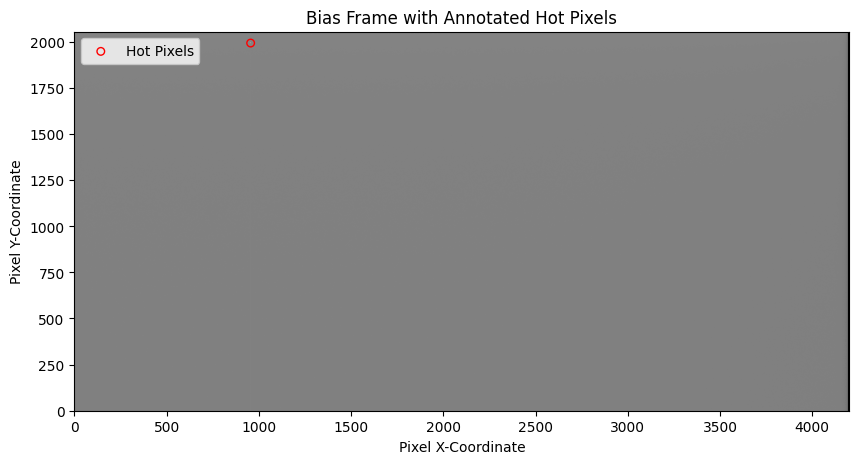

Number of hot pixels: 1


In [ ]:

# Function to plot a single bias frame and highlight hot pixels
def plot_bias_with_hot_pixels(bias_file, threshold_factor=2):
    # Open the FITS file
    with fits.open(bias_file) as hdul:
        data = hdul[0].data
        header = hdul[0].header

    # Calculate mean and standard deviation
    mean = np.mean(data)
    std = np.std(data)

    # Define the threshold for hot pixels
    threshold = mean + threshold_factor * std

    # Identify hot pixels
    hot_y, hot_x = np.where(data > threshold)

    # Plot the bias frame
    plt.figure(figsize=(10, 8))
    plt.imshow(data, cmap='gray', origin='lower', vmin=mean - 2 * std, vmax=mean + 2 * std)
    plt.xlabel('Pixel X-Coordinate')
    plt.ylabel('Pixel Y-Coordinate')
    plt.scatter(hot_x, hot_y, s=30, edgecolors='red', facecolors='none', label='Hot Pixels')
    plt.title('Bias Frame with Annotated Hot Pixels')
    plt.legend(loc='upper left')
    plt.show()

    # Print the number of hot pixels
    print(f"Number of hot pixels: {len(hot_x)}")

# Example usage
bias_file_path = "/Users/Ishfahanirusyda/Documents/Obstech/BiasFlats/BIAS/Red/master_bias_Red.fits"  # Replace with the actual file path
plot_bias_with_hot_pixels(bias_file_path, threshold_factor=5)

## Question 2. Creating master_bias

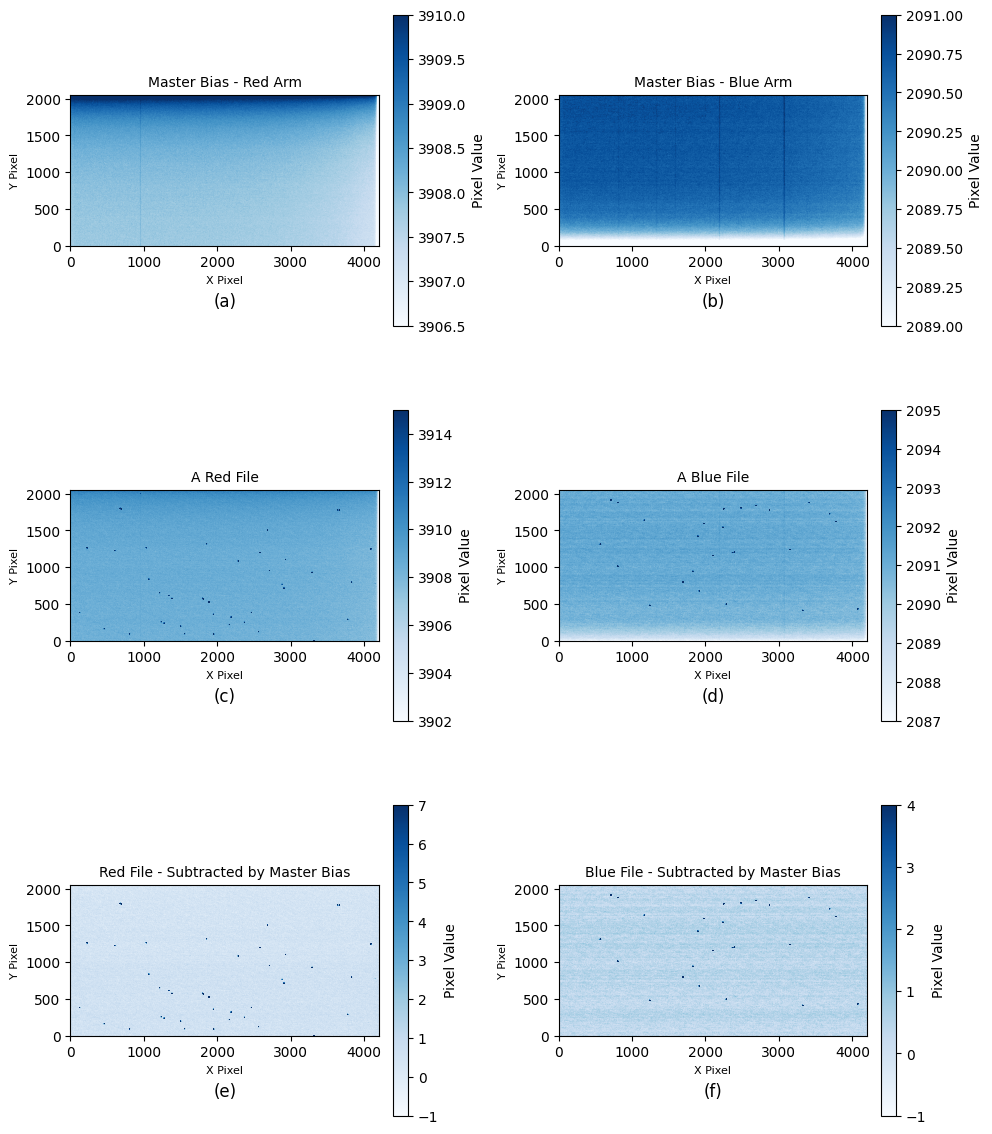

In [ ]:


# Function to create and plot master_bias for both arms side by side
def create_and_plot_master_bias(bias_red_folder, bias_blue_folder):
    def create_master_bias(bias_folder):
        bias_files = [os.path.join(bias_folder, f) for f in os.listdir(bias_folder) if f.lower().endswith(".fits")]
        bias_data = []

        for file in bias_files:
            with fits.open(file) as hdul:
                bias_data.append(hdul[0].data)

        # Calculate the median to create the master_bias
        return np.median(bias_data, axis=0), bias_files

    # Create master_bias for both arms
    master_bias_red, red_files = create_master_bias(bias_red_folder)
    master_bias_blue, blue_files = create_master_bias(bias_blue_folder)

    # Choose a random file from each arm
    random_red_file = random.choice(red_files)
    random_blue_file = random.choice(blue_files)

    with fits.open(random_red_file) as hdul:
        random_red_data = hdul[0].data

    with fits.open(random_blue_file) as hdul:
        random_blue_data = hdul[0].data

    # Subtract the random file from the master_bias
    red_subtracted = random_red_data - master_bias_red
    blue_subtracted = random_blue_data - master_bias_blue

    # Dynamically calculate the range for better visualization
    vmin_red = np.percentile(master_bias_red, 5)
    vmax_red = np.percentile(master_bias_red, 95)
    vmin_blue = np.percentile(master_bias_blue, 5)
    vmax_blue = np.percentile(master_bias_blue, 95)

    # Dynamically calculate the range for the random files
    vmin_random_red = np.percentile(random_red_data, 5)
    vmax_random_red = np.percentile(random_red_data, 95)
    vmin_random_blue = np.percentile(random_blue_data, 5)
    vmax_random_blue = np.percentile(random_blue_data, 95)

    # Dynamically calculate the range for the subtracted results
    vmin_subtracted_red = np.percentile(red_subtracted, 5)
    vmax_subtracted_red = np.percentile(red_subtracted, 95)
    vmin_subtracted_blue = np.percentile(blue_subtracted, 5)
    vmax_subtracted_blue = np.percentile(blue_subtracted, 95)

    # Plot both master_bias frames side by side with random file and subtraction result
    fig, axes = plt.subplots(3, 2, figsize=(10, 12))  # Adjusted for 3 rows and 2 columns

    # Plot Master Bias - Red Arm
    im1 = axes[0, 0].imshow(master_bias_red, cmap="Blues", origin="lower", vmin=vmin_red, vmax=vmax_red)
    axes[0, 0].set_title("Master Bias - Red Arm", fontsize=10)
    axes[0, 0].set_xlabel("X Pixel", fontsize=8)
    axes[0, 0].set_ylabel("Y Pixel", fontsize=8)
    plt.colorbar(im1, ax=axes[0, 0], fraction=0.046, pad=0.04, label="Pixel Value")
    axes[0, 0].text(0.5, -0.4, "(a)", transform=axes[0, 0].transAxes, fontsize=12, ha="center")

    # Plot Random Red File
    im2 = axes[1, 0].imshow(random_red_data, cmap="Blues", origin="lower", vmin=vmin_random_red, vmax=vmax_random_red)
    axes[1, 0].set_title("A Red File", fontsize=10)
    axes[1, 0].set_xlabel("X Pixel", fontsize=8)
    axes[1, 0].set_ylabel("Y Pixel", fontsize=8)
    plt.colorbar(im2, ax=axes[1, 0], fraction=0.046, pad=0.04, label="Pixel Value")
    axes[1, 0].text(0.5, -0.4, "(c)", transform=axes[1, 0].transAxes, fontsize=12, ha="center")

    # Plot Subtracted Red Result
    im3 = axes[2, 0].imshow(red_subtracted, cmap="Blues", origin="lower", vmin=-1, vmax=vmax_subtracted_red)
    axes[2, 0].set_title("Red File - Subtracted by Master Bias", fontsize=10)
    axes[2, 0].set_xlabel("X Pixel", fontsize=8)
    axes[2, 0].set_ylabel("Y Pixel", fontsize=8)
    plt.colorbar(im3, ax=axes[2, 0], fraction=0.046, pad=0.04, label="Pixel Value")
    axes[2, 0].text(0.5, -0.4, "(e)", transform=axes[2, 0].transAxes, fontsize=12, ha="center")

    # Plot Master Bias - Blue Arm
    im4 = axes[0, 1].imshow(master_bias_blue, cmap="Blues", origin="lower", vmin=vmin_blue, vmax=vmax_blue)
    axes[0, 1].set_title("Master Bias - Blue Arm", fontsize=10)
    axes[0, 1].set_xlabel("X Pixel", fontsize=8)
    axes[0, 1].set_ylabel("Y Pixel", fontsize=8)
    plt.colorbar(im4, ax=axes[0, 1], fraction=0.046, pad=0.04, label="Pixel Value")
    axes[0, 1].text(0.5, -0.4, "(b)", transform=axes[0, 1].transAxes, fontsize=12, ha="center")

    # Plot Random Blue File
    im5 = axes[1, 1].imshow(random_blue_data, cmap="Blues", origin="lower", vmin=vmin_random_blue, vmax=vmax_random_blue)
    axes[1, 1].set_title("A Blue File", fontsize=10)
    axes[1, 1].set_xlabel("X Pixel", fontsize=8)
    axes[1, 1].set_ylabel("Y Pixel", fontsize=8)
    plt.colorbar(im5, ax=axes[1, 1], fraction=0.046, pad=0.04, label="Pixel Value")
    axes[1, 1].text(0.5, -0.4, "(d)", transform=axes[1, 1].transAxes, fontsize=12, ha="center")

    # Plot Subtracted Blue Result
    im6 = axes[2, 1].imshow(blue_subtracted, cmap="Blues", origin="lower", vmin=-1, vmax=vmax_subtracted_blue)
    axes[2, 1].set_title("Blue File - Subtracted by Master Bias", fontsize=10)
    axes[2, 1].set_xlabel("X Pixel", fontsize=8)
    axes[2, 1].set_ylabel("Y Pixel", fontsize=8)
    plt.colorbar(im6, ax=axes[2, 1], fraction=0.046, pad=0.04, label="Pixel Value")
    axes[2, 1].text(0.5, -0.4, "(f)", transform=axes[2, 1].transAxes, fontsize=12, ha="center")

    # Adjust layout for better spacing
    plt.tight_layout()
    plt.show()

# Call the function to create and plot master_bias for both arms
create_and_plot_master_bias(bias_red_folder, bias_blue_folder)

## Question 3. Detector linearity of flat files

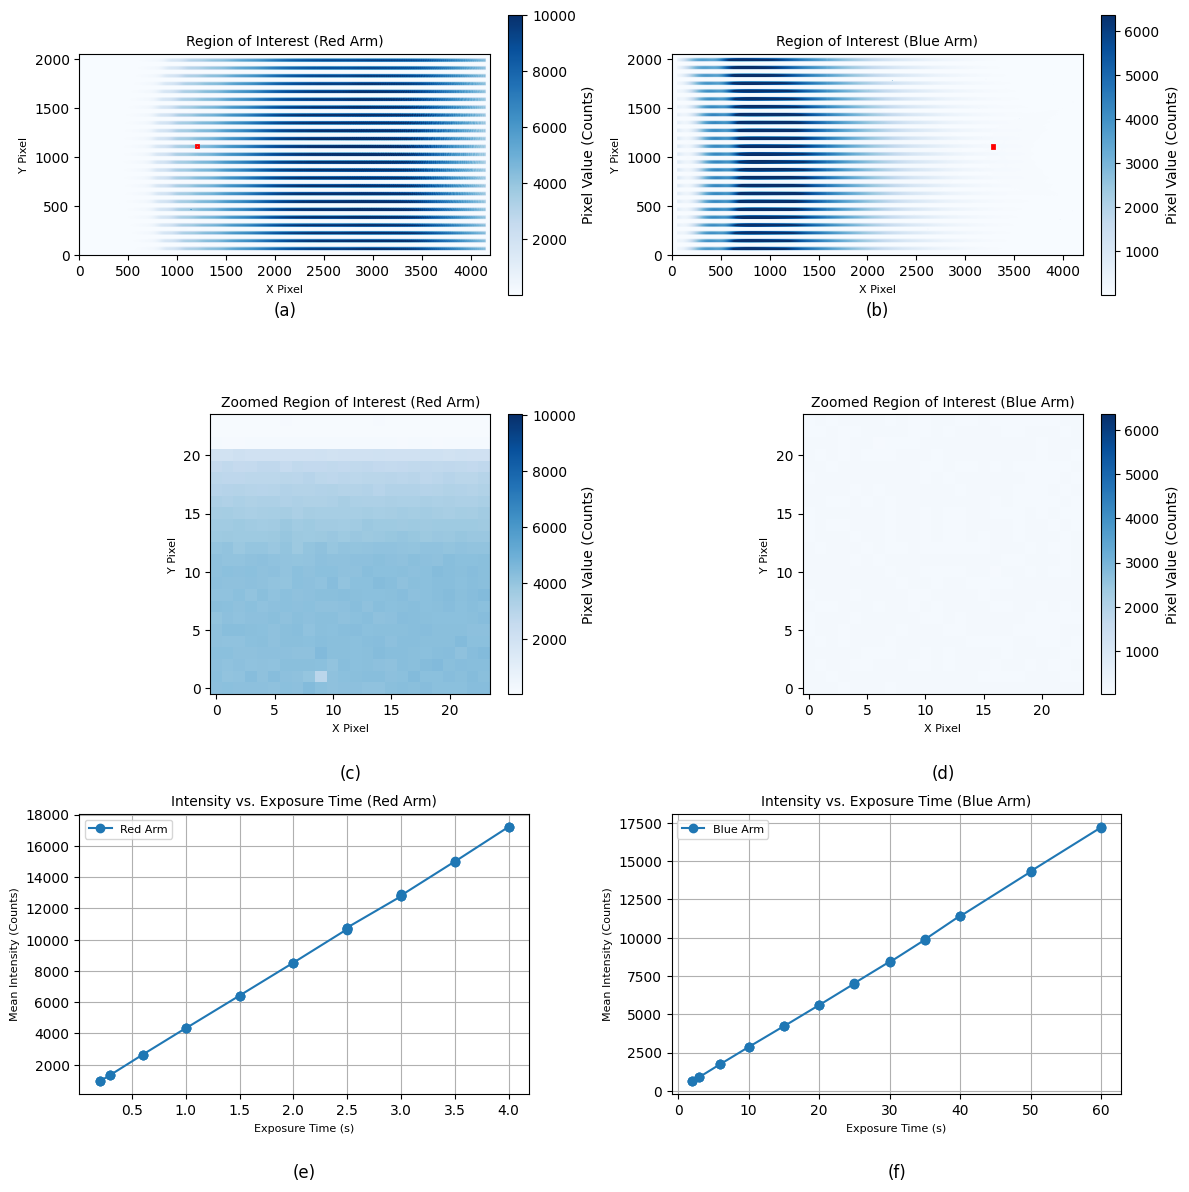

In [ ]:
# Modified code to add different region of interest positions for blue and red arms
# Function to calculate intensity vs. exposure time for a region of interest
def plot_intensity_vs_exptime(flat_folder, master_bias, arm_name, axes, col_index):
    flat_files = [os.path.join(flat_folder, f) for f in os.listdir(flat_folder) if f.lower().endswith(".fits")]
    exposure_times = []
    intensities = []

    # Choose the first flat file to visualize the region of interest
    example_flat_file = flat_files[0]

    for flat_file in flat_files:
        with fits.open(flat_file) as hdul:
            header = hdul[0].header
            data = hdul[0].data

            # Subtract the master bias
            data_corrected = data - master_bias

            # Extract the exposure time from the header
            exptime = header.get("EXPTIME", None)
            if exptime is None:
                print(f"Exposure time not found in {flat_file}, skipping.")
                continue

            # Define a square region with different offsets for red and blue arms
            center_x, center_y = data_corrected.shape[1] // 2, data_corrected.shape[0] // 2
            region_size = 25  # Size of the square region (e.g., 50x50 pixels)

            if arm_name == "Red":
                offset_x = 900  # Shift the region slightly to the left for the red arm
                offset_y= -88
            elif arm_name == "Blue":
                offset_x = -1180 # Shift the region further to the left for the blue arm
                offset_y = -80
            else:
                offset_x = 0  # Default offset if arm is not recognized
                offset_y = 0

    
            region = data_corrected[
                center_y + offset_y - region_size // 2 : center_y + offset_y + region_size // 2,
                center_x + offset_x - region_size // 2 : center_x + offset_x + region_size // 2
            ]

            # Calculate the mean intensity in the region
            mean_intensity = np.mean(region)

            # Append the exposure time and intensity
            exposure_times.append(exptime)
            intensities.append(mean_intensity)

    # Sort the data by exposure time
    sorted_indices = np.argsort(exposure_times)
    exposure_times = np.array(exposure_times)[sorted_indices]
    intensities = np.array(intensities)[sorted_indices]

    # Plot the region of interest on the example flat file
    with fits.open(example_flat_file) as hdul:
        example_data = hdul[0].data - master_bias

    # Normalize the color scale for the region of interest
    vmin = np.percentile(example_data, 5)
    vmax = np.percentile(example_data, 95)

    # Plot the full region of interest
    ax_roi = axes[0, col_index]
    im = ax_roi.imshow(example_data, cmap="Blues", origin="lower", vmin=vmin, vmax=vmax)
    ax_roi.set_title(f"Region of Interest ({arm_name} Arm)", fontsize=10)
    ax_roi.set_xlabel("X Pixel", fontsize=8)
    ax_roi.set_ylabel("Y Pixel", fontsize=8)
    plt.colorbar(im, ax=ax_roi, fraction=0.046, pad=0.04, label="Pixel Value (Counts)")

    # Highlight the region of interest
    rect = plt.Rectangle(
        (center_x - offset_x - region_size // 2, center_y - offset_y - region_size // 2),
        region_size,
        region_size,
        edgecolor="red",
        facecolor="none",
        linewidth=2,
    )
    ax_roi.add_patch(rect)

    # Plot the zoomed-in region of interest
    ax_zoom = axes[1, col_index]
    zoomed_region = example_data[
        center_y - offset_y - region_size // 2 : center_y - offset_y + region_size // 2,
        center_x - offset_x - region_size // 2 : center_x - offset_x + region_size // 2
    ]
    im_zoom = ax_zoom.imshow(zoomed_region, cmap="Blues", origin="lower", vmin=vmin, vmax=vmax)
    ax_zoom.set_title(f"Zoomed Region of Interest ({arm_name} Arm)", fontsize=10)
    ax_zoom.set_xlabel("X Pixel", fontsize=8)
    ax_zoom.set_ylabel("Y Pixel", fontsize=8)
    plt.colorbar(im_zoom, ax=ax_zoom, fraction=0.046, pad=0.04, label="Pixel Value (Counts)")

    # Plot Intensity vs. Exposure Time
    ax_linearity = axes[2, col_index]
    ax_linearity.plot(exposure_times, intensities, marker="o", linestyle="-", label=f"{arm_name} Arm")
    ax_linearity.set_xlabel("Exposure Time (s)", fontsize=8)
    ax_linearity.set_ylabel("Mean Intensity (Counts)", fontsize=8)
    ax_linearity.set_title(f"Intensity vs. Exposure Time ({arm_name} Arm)", fontsize=10)
    ax_linearity.grid(True)
    ax_linearity.legend(fontsize=8)


master_bias_red_path = '/Users/ishfahanirusyda/Documents/Obstech/BiasFlats/BIAS/Red/master_bias_Red.fits'
master_bias_blue_path = '/Users/ishfahanirusyda/Documents/Obstech/BiasFlats/BIAS/Blue/master_bias_Blue.fits'

with fits.open(master_bias_red_path) as hdul:
    master_bias_red = hdul[0].data

with fits.open(master_bias_blue_path) as hdul:
    master_bias_blue = hdul[0].data

# Create a single figure with 6 subplots (3 rows, 2 columns)
fig, axes = plt.subplots(3, 2, figsize=(12, 12))  # 3 rows, 2 columns for side-by-side plots

# Plot for the red arm
plot_intensity_vs_exptime(flats_red_folder, master_bias_red, "Red", axes, col_index=0)

# Plot for the blue arm
plot_intensity_vs_exptime(flats_blue_folder, master_bias_blue, "Blue", axes, col_index=1)

# Adjust positions for subfigure captions
axes[0, 0].text(0.5, -0.3, "(a)", transform=axes[0, 0].transAxes, fontsize=12, ha="center")
axes[1, 0].text(0.5, -0.2, "(c)", transform=axes[1, 0].transAxes, fontsize=12, ha="center")
axes[2, 0].text(0.5, -0.3, "(e)", transform=axes[2, 0].transAxes, fontsize=12, ha="center")
axes[0, 1].text(0.5, -0.3, "(b)", transform=axes[0, 1].transAxes, fontsize=12, ha="center")
axes[1, 1].text(0.5, -0.2, "(d)", transform=axes[1, 1].transAxes, fontsize=12, ha="center")
axes[2, 1].text(0.5, -0.3, "(f)", transform=axes[2, 1].transAxes, fontsize=12, ha="center")

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

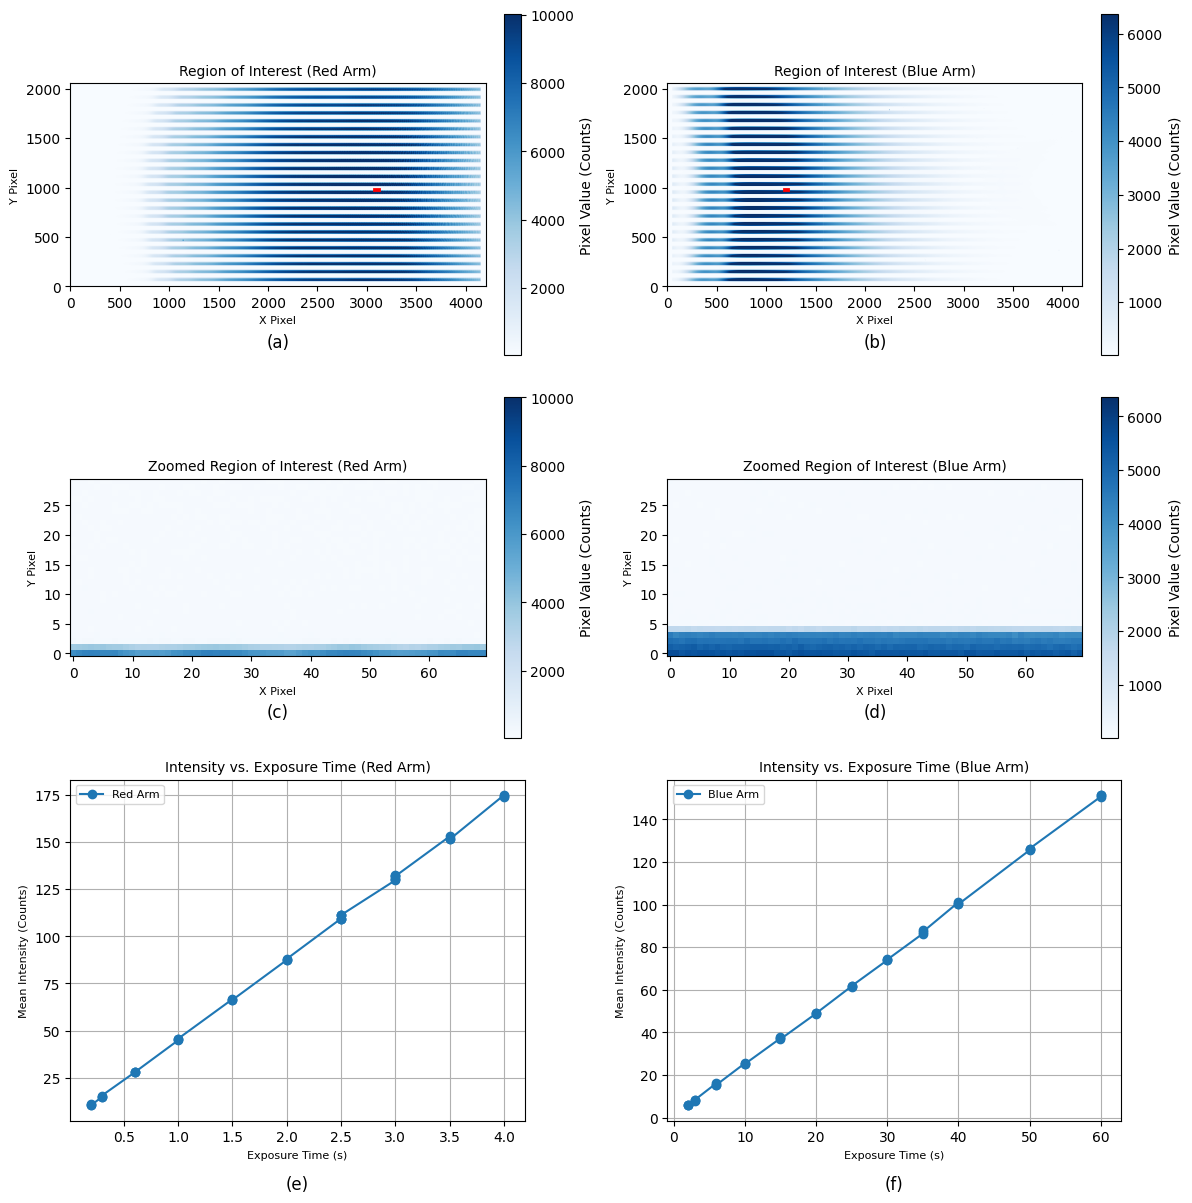

In [ ]:

# Function to calculate intensity vs. exposure time for a region of interest
def plot_intensity_vs_exptime(flat_folder, master_bias, arm_name, axes, col_index):
    flat_files = [os.path.join(flat_folder, f) for f in os.listdir(flat_folder) if f.lower().endswith(".fits")]
    exposure_times = []
    intensities = []

    # Choose the first flat file to visualize the region of interest
    example_flat_file = flat_files[0]

    for flat_file in flat_files:
        with fits.open(flat_file) as hdul:
            header = hdul[0].header
            data = hdul[0].data

            # Subtract the master bias
            data_corrected = data - master_bias

            # Extract the exposure time from the header
            exptime = header.get("EXPTIME", None)
            if exptime is None:
                print(f"Exposure time not found in {flat_file}, skipping.")
                continue

            # Define a rectangular region with different offsets for red and blue arms
            center_x, center_y = data_corrected.shape[1] // 2, data_corrected.shape[0] // 2
            region_width = 50  # Width of the rectangular region
            region_height = 10  # Height of the rectangular region

            if arm_name == "Red":
                offset_x = 1000  # Shift the region slightly to the left for the red arm
                offset_y = -50
            elif arm_name == "Blue":
                offset_x = -900  # Shift the region further to the left for the blue arm
                offset_y = -50
            else:
                offset_x = 0  # Default offset if arm is not recognized
                offset_y = 0

            region = data_corrected[
                center_y + offset_y - region_height // 2 : center_y + offset_y + region_height // 2,
                center_x + offset_x - region_width // 2 : center_x + offset_x + region_width // 2
            ]

            # Calculate the mean intensity in the region
            mean_intensity = np.mean(region)

            # Append the exposure time and intensity
            exposure_times.append(exptime)
            intensities.append(mean_intensity)

    # Sort the data by exposure time
    sorted_indices = np.argsort(exposure_times)
    exposure_times = np.array(exposure_times)[sorted_indices]
    intensities = np.array(intensities)[sorted_indices]

    # Plot the region of interest on the example flat file
    with fits.open(example_flat_file) as hdul:
        example_data = hdul[0].data - master_bias

    # Normalize the color scale for the region of interest
    vmin = np.percentile(example_data, 5)
    vmax = np.percentile(example_data, 95)

    # Plot the full region of interest
    ax_roi = axes[0, col_index]
    im = ax_roi.imshow(example_data, cmap="Blues", origin="lower", vmin=vmin, vmax=vmax)
    ax_roi.set_title(f"Region of Interest ({arm_name} Arm)", fontsize=10)
    ax_roi.set_xlabel("X Pixel", fontsize=8)
    ax_roi.set_ylabel("Y Pixel", fontsize=8)
    plt.colorbar(im, ax=ax_roi, fraction=0.046, pad=0.04, label="Pixel Value (Counts)")

    # Highlight the region of interest
    rect = plt.Rectangle(
        (center_x + offset_x - region_width // 2, center_y + offset_y - region_height // 2),
        region_width,
        region_height,
        edgecolor="red",
        facecolor="none",
        linewidth=2,
    )
    ax_roi.add_patch(rect)

    # Plot the zoomed-in region of interest
    zoom_margin = 10  # Add margin around the ROI for better context
    ax_zoom = axes[1, col_index]
    zoomed_region = example_data[
        center_y + offset_y - region_height // 2 - zoom_margin : center_y + offset_y + region_height // 2 + zoom_margin,
        center_x + offset_x - region_width // 2 - zoom_margin : center_x + offset_x + region_width // 2 + zoom_margin
    ]
    im_zoom = ax_zoom.imshow(zoomed_region, cmap="Blues", origin="lower", vmin=vmin, vmax=vmax)
    ax_zoom.set_title(f"Zoomed Region of Interest ({arm_name} Arm)", fontsize=10)
    ax_zoom.set_xlabel("X Pixel", fontsize=8)
    ax_zoom.set_ylabel("Y Pixel", fontsize=8)
    plt.colorbar(im_zoom, ax=ax_zoom, fraction=0.046, pad=0.04, label="Pixel Value (Counts)")

    # Plot Intensity vs. Exposure Time
    ax_linearity = axes[2, col_index]
    ax_linearity.plot(exposure_times, intensities, marker="o", linestyle="-", label=f"{arm_name} Arm")
    ax_linearity.set_xlabel("Exposure Time (s)", fontsize=8)
    ax_linearity.set_ylabel("Mean Intensity (Counts)", fontsize=8)
    ax_linearity.set_title(f"Intensity vs. Exposure Time ({arm_name} Arm)", fontsize=10)
    ax_linearity.grid(True)
    ax_linearity.legend(fontsize=8)


master_bias_red_path = '/Users/ishfahanirusyda/Documents/Obstech/BiasFlats/BIAS/Red/master_bias_Red.fits'
master_bias_blue_path = '/Users/ishfahanirusyda/Documents/Obstech/BiasFlats/BIAS/Blue/master_bias_Blue.fits'

with fits.open(master_bias_red_path) as hdul:
    master_bias_red = hdul[0].data

with fits.open(master_bias_blue_path) as hdul:
    master_bias_blue = hdul[0].data

# Create a single figure with 6 subplots (3 rows, 2 columns)
fig, axes = plt.subplots(3, 2, figsize=(12, 12))  # 3 rows, 2 columns for side-by-side plots

# Plot for the red arm
plot_intensity_vs_exptime(flats_red_folder, master_bias_red, "Red", axes, col_index=0)

# Plot for the blue arm
plot_intensity_vs_exptime(flats_blue_folder, master_bias_blue, "Blue", axes, col_index=1)

# Adjust positions for subfigure captions
axes[0, 0].text(0.5, -0.3, "(a)", transform=axes[0, 0].transAxes, fontsize=12, ha="center")
axes[1, 0].text(0.5, -0.34, "(c)", transform=axes[1, 0].transAxes, fontsize=12, ha="center")
axes[2, 0].text(0.5, -0.2, "(e)", transform=axes[2, 0].transAxes, fontsize=12, ha="center")
axes[0, 1].text(0.5, -0.3, "(b)", transform=axes[0, 1].transAxes, fontsize=12, ha="center")
axes[1, 1].text(0.5, -0.34, "(d)", transform=axes[1, 1].transAxes, fontsize=12, ha="center")
axes[2, 1].text(0.5, -0.2, "(f)", transform=axes[2, 1].transAxes, fontsize=12, ha="center")

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

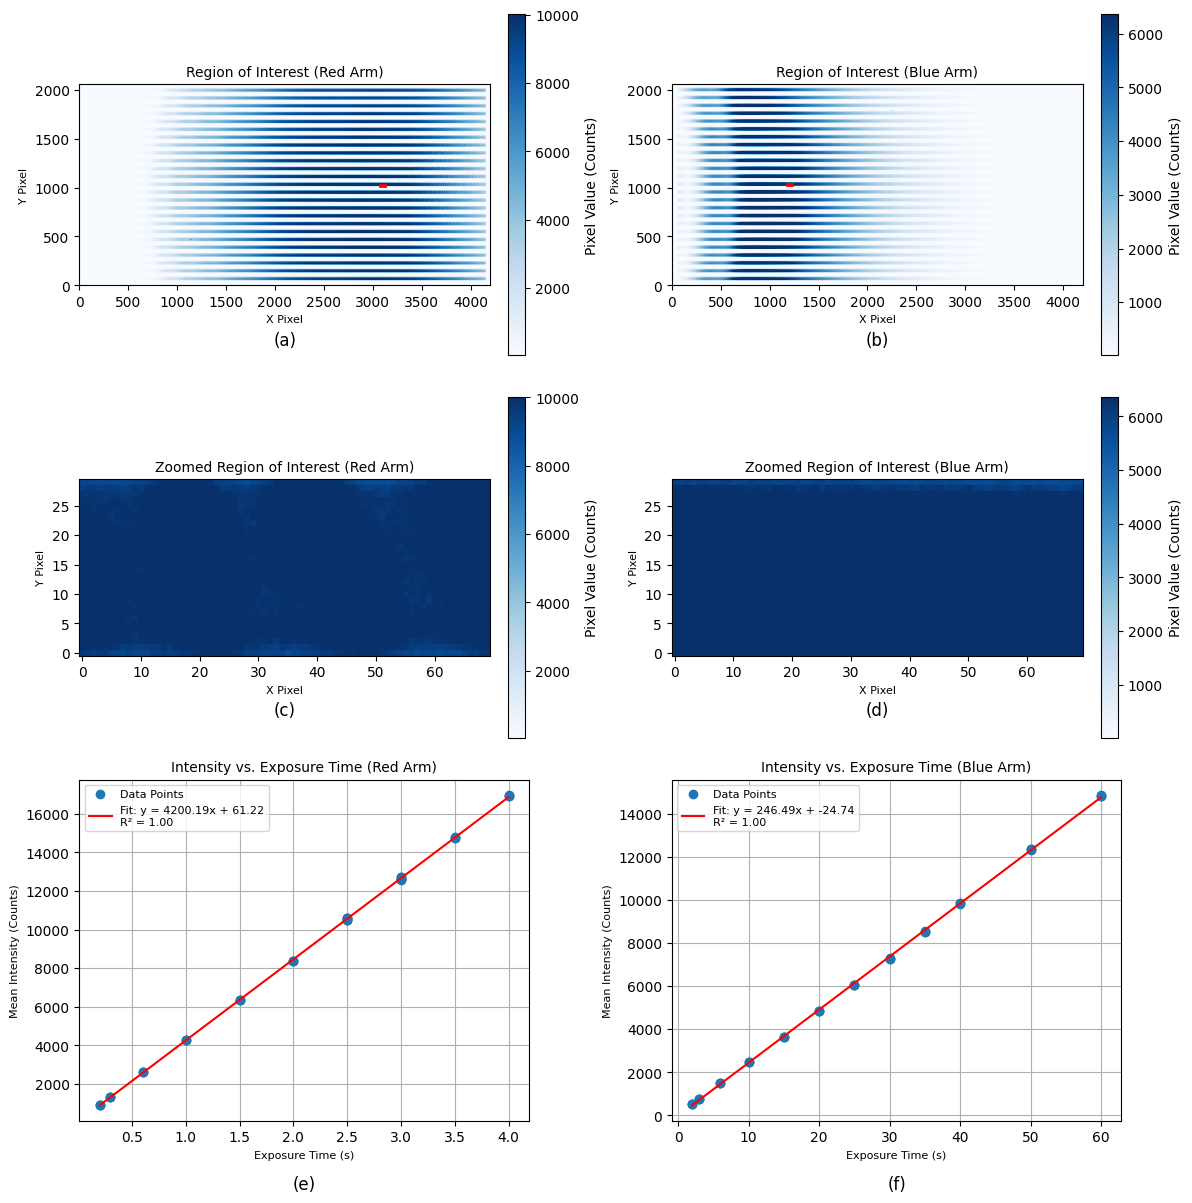

In [ ]:
# Function to calculate intensity vs. exposure time for a region of interest
def plot_intensity_vs_exptime(flat_folder, master_bias, arm_name, axes, col_index):
    flat_files = [os.path.join(flat_folder, f) for f in os.listdir(flat_folder) if f.lower().endswith(".fits")]
    exposure_times = []
    intensities = []

    # Choose the first flat file to visualize the region of interest
    example_flat_file = flat_files[0]

    for flat_file in flat_files:
        with fits.open(flat_file) as hdul:
            header = hdul[0].header
            data = hdul[0].data

            # Subtract the master bias
            data_corrected = data - master_bias

            # Extract the exposure time from the header
            exptime = header.get("EXPTIME", None)
            if exptime is None:
                print(f"Exposure time not found in {flat_file}, skipping.")
                continue

            # Define a rectangular region with different offsets for red and blue arms
            center_x, center_y = data_corrected.shape[1] // 2, data_corrected.shape[0] // 2
            region_width = 50  # Width of the rectangular region
            region_height = 10  # Height of the rectangular region

            if arm_name == "Red":
                offset_x = 1000  # Shift the region slightly to the left for the red arm
                offset_y = -6
            elif arm_name == "Blue":
                offset_x = -900  # Shift the region further to the left for the blue arm
                offset_y = 0
            else:
                offset_x = 0  # Default offset if arm is not recognized
                offset_y = 0

            region = data_corrected[
                center_y + offset_y - region_height // 2 : center_y + offset_y + region_height // 2,
                center_x + offset_x - region_width // 2 : center_x + offset_x + region_width // 2
            ]

            # Calculate the mean intensity in the region
            mean_intensity = np.mean(region)

            # Append the exposure time and intensity
            exposure_times.append(exptime)
            intensities.append(mean_intensity)

    # Sort the data by exposure time
    sorted_indices = np.argsort(exposure_times)
    exposure_times = np.array(exposure_times)[sorted_indices]
    intensities = np.array(intensities)[sorted_indices]

    # Perform a linear fit
    slope, intercept, r_value, _, _ = linregress(exposure_times, intensities)

    # Plot the region of interest on the example flat file
    with fits.open(example_flat_file) as hdul:
        example_data = hdul[0].data - master_bias

    # Normalize the color scale for the region of interest
    vmin = np.percentile(example_data, 5)
    vmax = np.percentile(example_data, 95)

    # Plot the full region of interest
    ax_roi = axes[0, col_index]
    im = ax_roi.imshow(example_data, cmap="Blues", origin="lower", vmin=vmin, vmax=vmax)
    ax_roi.set_title(f"Region of Interest ({arm_name} Arm)", fontsize=10)
    ax_roi.set_xlabel("X Pixel", fontsize=8)
    ax_roi.set_ylabel("Y Pixel", fontsize=8)
    plt.colorbar(im, ax=ax_roi, fraction=0.046, pad=0.04, label="Pixel Value (Counts)")

    # Highlight the region of interest
    rect = plt.Rectangle(
        (center_x + offset_x - region_width // 2, center_y + offset_y - region_height // 2),
        region_width,
        region_height,
        edgecolor="red",
        facecolor="none",
        linewidth=2,
    )
    ax_roi.add_patch(rect)

    # Plot the zoomed-in region of interest
    zoom_margin = 10  # Add margin around the ROI for better context
    ax_zoom = axes[1, col_index]
    zoomed_region = example_data[
        center_y + offset_y - region_height // 2 - zoom_margin : center_y + offset_y + region_height // 2 + zoom_margin,
        center_x + offset_x - region_width // 2 - zoom_margin : center_x + offset_x + region_width // 2 + zoom_margin
    ]
    im_zoom = ax_zoom.imshow(zoomed_region, cmap="Blues", origin="lower", vmin=vmin, vmax=vmax)
    ax_zoom.set_title(f"Zoomed Region of Interest ({arm_name} Arm)", fontsize=10)
    ax_zoom.set_xlabel("X Pixel", fontsize=8)
    ax_zoom.set_ylabel("Y Pixel", fontsize=8)
    plt.colorbar(im_zoom, ax=ax_zoom, fraction=0.046, pad=0.04, label="Pixel Value (Counts)")

    # Plot Intensity vs. Exposure Time with linear fit
    ax_linearity = axes[2, col_index]
    ax_linearity.plot(exposure_times, intensities, marker="o", linestyle="", label="Data Points")
    ax_linearity.plot(exposure_times, slope * exposure_times + intercept, color="red", label=f"Fit: y = {slope:.2f}x + {intercept:.2f}\nR² = {r_value**2:.2f}")
    ax_linearity.set_xlabel("Exposure Time (s)", fontsize=8)
    ax_linearity.set_ylabel("Mean Intensity (Counts)", fontsize=8)
    ax_linearity.set_title(f"Intensity vs. Exposure Time ({arm_name} Arm)", fontsize=10)
    ax_linearity.grid(True)
    ax_linearity.legend(fontsize=8)


master_bias_red_path = '/Users/ishfahanirusyda/Documents/Obstech/BiasFlats/BIAS/Red/master_bias_Red.fits'
master_bias_blue_path = '/Users/ishfahanirusyda/Documents/Obstech/BiasFlats/BIAS/Blue/master_bias_Blue.fits'

with fits.open(master_bias_red_path) as hdul:
    master_bias_red = hdul[0].data

with fits.open(master_bias_blue_path) as hdul:
    master_bias_blue = hdul[0].data

# Create a single figure with 6 subplots (3 rows, 2 columns)
fig, axes = plt.subplots(3, 2, figsize=(12, 12))  # 3 rows, 2 columns for side-by-side plots

# Plot for the red arm
plot_intensity_vs_exptime(flats_red_folder, master_bias_red, "Red", axes, col_index=0)

# Plot for the blue arm
plot_intensity_vs_exptime(flats_blue_folder, master_bias_blue, "Blue", axes, col_index=1)

# Adjust positions for subfigure captions
axes[0, 0].text(0.5, -0.3, "(a)", transform=axes[0, 0].transAxes, fontsize=12, ha="center")
axes[1, 0].text(0.5, -0.34, "(c)", transform=axes[1, 0].transAxes, fontsize=12, ha="center")
axes[2, 0].text(0.5, -0.2, "(e)", transform=axes[2, 0].transAxes, fontsize=12, ha="center")
axes[0, 1].text(0.5, -0.3, "(b)", transform=axes[0, 1].transAxes, fontsize=12, ha="center")
axes[1, 1].text(0.5, -0.34, "(d)", transform=axes[1, 1].transAxes, fontsize=12, ha="center")
axes[2, 1].text(0.5, -0.2, "(f)", transform=axes[2, 1].transAxes, fontsize=12, ha="center")

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

## Question 4. initial noise estimate (bias frame)

14773 676
65535 0


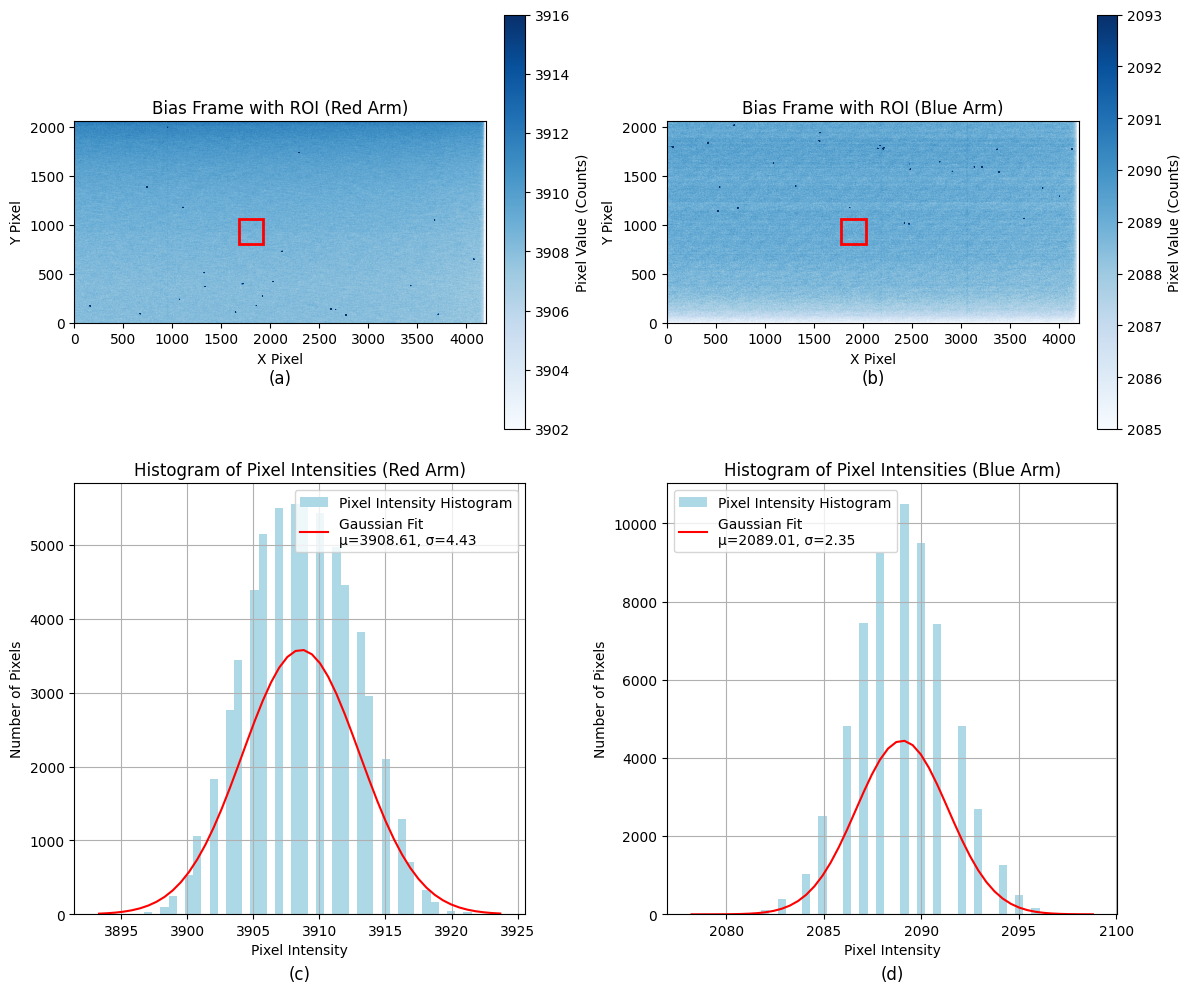

Standard Deviation in Region (Red Arm): 4.01 ADU
Standard Deviation in Region (Blue Arm): 2.39 ADU
Gaussian Fit Parameters for Red Arm: μ=3908.61, σ=4.43
Gaussian Fit Parameters for Blue Arm: μ=2089.01, σ=2.35


In [ ]:
# Define a Gaussian function
def gaussian(x, a, mu, sigma):
    return a * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

# Define region of interest for bias, subtract master bias, calculate standard deviation, and plot side by side
def calculate_stddev_and_plot_roi_with_histograms(bias_file_red, bias_file_blue, master_bias_red, master_bias_blue, region_size, red_offset, blue_offset):
    def process_bias_file(bias_file, master_bias, arm_name, offset_x, offset_y):
        with fits.open(bias_file) as hdul:
            bias_data = hdul[0].data

            # Subtract the master bias
            bias_data_corrected = bias_data 
            print(np.max(bias_data_corrected), np.min(bias_data_corrected))

            # Define a square region in the frame with offsets
            center_x, center_y = bias_data_corrected.shape[1] // 2, bias_data_corrected.shape[0] // 2
            region = bias_data_corrected[
                center_y + offset_y - region_size // 2 : center_y + offset_y + region_size // 2,
                center_x + offset_x - region_size // 2 : center_x + offset_x + region_size // 2
            ]

            # Calculate the standard deviation in the region
            stddev = np.std(region)

            # Calculate vmin and vmax using percentiles for better visualization
            vmin = np.percentile(bias_data_corrected, 5)
            vmax = np.percentile(bias_data_corrected, 95)

            return bias_data_corrected, region, stddev, vmin, vmax

    # Process red and blue bias files with their respective offsets
    bias_data_red, region_red, stddev_red, vmin_red, vmax_red = process_bias_file(
        bias_file_red, master_bias_red, "Red", red_offset[0], red_offset[1]
    )
    bias_data_blue, region_blue, stddev_blue, vmin_blue, vmax_blue = process_bias_file(
        bias_file_blue, master_bias_blue, "Blue", blue_offset[0], blue_offset[1]
    )

    # Create a 2-row plot: first row for bias frames, second row for histograms
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))  # 2 rows, 2 columns

    # Plot Red Arm Bias Frame
    im_red = axes[0, 0].imshow(bias_data_red, cmap="Blues", origin="lower", vmin=vmin_red, vmax=vmax_red)
    axes[0, 0].set_title("Bias Frame with ROI (Red Arm)", fontsize=12)
    axes[0, 0].set_xlabel("X Pixel", fontsize=10)
    axes[0, 0].set_ylabel("Y Pixel", fontsize=10)
    plt.colorbar(im_red, ax=axes[0, 0], fraction=0.046, pad=0.04, label="Pixel Value (Counts)")
    axes[0, 0].text(0.5, -0.3, "(a)", transform=axes[0, 0].transAxes, fontsize=12, ha="center")

    # Highlight the region of interest for Red Arm
    rect_red = plt.Rectangle(
        (bias_data_red.shape[1] // 2 + red_offset[0] - region_size // 2, bias_data_red.shape[0] // 2 + red_offset[1] - region_size // 2),
        region_size,
        region_size,
        edgecolor="red",
        facecolor="none",
        linewidth=2,
    )
    axes[0, 0].add_patch(rect_red)

    # Plot Blue Arm Bias Frame
    im_blue = axes[0, 1].imshow(bias_data_blue, cmap="Blues", origin="lower", vmin=vmin_blue, vmax=vmax_blue)
    axes[0, 1].set_title("Bias Frame with ROI (Blue Arm)", fontsize=12)
    axes[0, 1].set_xlabel("X Pixel", fontsize=10)
    axes[0, 1].set_ylabel("Y Pixel", fontsize=10)
    plt.colorbar(im_blue, ax=axes[0, 1], fraction=0.046, pad=0.04, label="Pixel Value (Counts)")
    axes[0, 1].text(0.5, -0.3, "(b)", transform=axes[0, 1].transAxes, fontsize=12, ha="center")

    # Highlight the region of interest for Blue Arm
    rect_blue = plt.Rectangle(
        (bias_data_blue.shape[1] // 2 + blue_offset[0] - region_size // 2, bias_data_blue.shape[0] // 2 + blue_offset[1] - region_size // 2),
        region_size,
        region_size,
        edgecolor="red",
        facecolor="none",
        linewidth=2,
    )
    axes[0, 1].add_patch(rect_blue)

    # Plot Red Arm Histogram
    pixel_values_red = region_red.flatten()
    hist_red, bin_edges_red = np.histogram(pixel_values_red, bins=50)
    bin_centers_red = (bin_edges_red[:-1] + bin_edges_red[1:]) / 2
    popt_red, _ = curve_fit(gaussian, bin_centers_red, hist_red, p0=[np.max(hist_red), np.mean(pixel_values_red), np.std(pixel_values_red)])
    axes[1, 0].hist(pixel_values_red, bins=50, color="lightblue", label="Pixel Intensity Histogram")
    axes[1, 0].plot(bin_centers_red, gaussian(bin_centers_red, *popt_red), color="red", label=f"Gaussian Fit\nμ={popt_red[1]:.2f}, σ={popt_red[2]:.2f}")
    axes[1, 0].set_title("Histogram of Pixel Intensities (Red Arm)", fontsize=12)
    axes[1, 0].set_xlabel("Pixel Intensity", fontsize=10)
    axes[1, 0].set_ylabel("Number of Pixels", fontsize=10)
    axes[1, 0].legend(fontsize=10)
    axes[1, 0].grid(True)
    axes[1, 0].text(0.5, -0.15, "(c)", transform=axes[1, 0].transAxes, fontsize=12, ha="center")

    # Plot Blue Arm Histogram
    pixel_values_blue = region_blue.flatten()
    hist_blue, bin_edges_blue = np.histogram(pixel_values_blue, bins=50)
    bin_centers_blue = (bin_edges_blue[:-1] + bin_edges_blue[1:]) / 2
    popt_blue, _ = curve_fit(gaussian, bin_centers_blue, hist_blue, p0=[np.max(hist_blue), np.mean(pixel_values_blue), np.std(pixel_values_blue)])
    axes[1, 1].hist(pixel_values_blue, bins=50,  color="lightblue", label="Pixel Intensity Histogram")
    axes[1, 1].plot(bin_centers_blue, gaussian(bin_centers_blue, *popt_blue), color="red", label=f"Gaussian Fit\nμ={popt_blue[1]:.2f}, σ={popt_blue[2]:.2f}")
    axes[1, 1].set_title("Histogram of Pixel Intensities (Blue Arm)", fontsize=12)
    axes[1, 1].set_xlabel("Pixel Intensity", fontsize=10)
    axes[1, 1].set_ylabel("Number of Pixels", fontsize=10)
    axes[1, 1].legend(fontsize=10)
    axes[1, 1].grid(True)
    axes[1, 1].text(0.5, -0.15, "(d)", transform=axes[1, 1].transAxes, fontsize=12, ha="center")

    # Adjust layout for better spacing
    plt.tight_layout()
    plt.show()

    # Print standard deviation results
    print(f"Standard Deviation in Region (Red Arm): {stddev_red:.2f} ADU")
    print(f"Standard Deviation in Region (Blue Arm): {stddev_blue:.2f} ADU")
    print(f"Gaussian Fit Parameters for Red Arm: μ={popt_red[1]:.2f}, σ={popt_red[2]:.2f}")
    print(f"Gaussian Fit Parameters for Blue Arm: μ={popt_blue[1]:.2f}, σ={popt_blue[2]:.2f}")

    return region_red, region_blue

# Load the master bias for both arms
with fits.open(os.path.join(bias_red_folder, "master_bias_Red.fits")) as hdul:
    master_bias_red = hdul[0].data

with fits.open(os.path.join(bias_blue_folder, "master_bias_Blue.fits")) as hdul:
    master_bias_blue = hdul[0].data

# Example usage
#bias_file_path_red = os.path.join(bias_red_folder, "OBK-709088-WiFeS-Red--UT20250314T230211-9.fits")  # Replace with actual file
#bias_file_path_blue = os.path.join(bias_blue_folder, "OBK-709088-WiFeS-Blue-UT20250314T231436-1.fits")  # Replace with actual file

bias_file_path_red_1 = os.path.join(bias_red_folder, "OBK-709088-WiFeS-Red--UT20250314T230114-7.fits")  # Replace with actual file
bias_file_path_red_2 = os.path.join(bias_red_folder, "OBK-709088-WiFeS-Red--UT20250314T230211-9.fits")  # Replace with actual file
bias_file_path_blue_1 = os.path.join(bias_blue_folder, "OBK-709088-WiFeS-Blue-UT20250314T231436-1.fits")  # Replace with actual file
bias_file_path_blue_2 = os.path.join(bias_blue_folder, "OBK-709088-WiFeS-Blue-UT20250314T230211-9.fits")  # Replace with actual file

# Define offsets for the red and blue arms (x_offset, y_offset)
red_offset = (-300, -100)  # Example: move ROI 300 pixels left for red arm
blue_offset = (-200, -100)  # Example: move ROI 800 pixels right for blue arm

region_red_run, region_blue_run = calculate_stddev_and_plot_roi_with_histograms(
    bias_file_path_red_2, bias_file_path_blue_2, master_bias_red, master_bias_blue, region_size=250, red_offset=red_offset, blue_offset=blue_offset
)

[[3908. 3913. 3908. ...  678. 3911. 3906.]
 [3915. 3904. 3910. ...  680. 3910. 3904.]
 [3912. 3910. 3908. ...  679. 3911. 3909.]
 ...
 [3917. 3923. 3925. ...  686. 3918. 3926.]
 [3919. 3920. 3927. ...  687. 3922. 3916.]
 [3929. 3917. 3922. ...  669. 3908. 3903.]]
[[3903. 3911. 3909. ...  679. 3907. 3910.]
 [3903. 3912. 3909. ...  679. 3901. 3912.]
 [3911. 3907. 3914. ...  677. 3905. 3907.]
 ...
 [3908. 3908. 3914. ...  677. 3908. 3913.]
 [3908. 3916. 3910. ...  678. 3912. 3914.]
 [3910. 3910. 3909. ...  688. 3908. 3907.]]
[[ -5.  -2.   1. ...   1.  -4.   4.]
 [-12.   8.  -1. ...  -1.  -9.   8.]
 [ -1.  -3.   6. ...  -2.  -6.  -2.]
 ...
 [ -9. -15. -11. ...  -9. -10. -13.]
 [-11.  -4. -17. ...  -9. -10.  -2.]
 [-19.  -7. -13. ...  19.   0.   4.]]
Standard Deviation in Region (Red Arm): 3.98 ADU
Standard Deviation in Region (Blue Arm): 4.02 ADU
Standard Deviation (theoretica):l): 5.663 ADU
Standard Deviation in Region (Combined): 5.59 ADU
[[2088. 2084. 2087. ...    0. 2091. 2091.]
 [2086

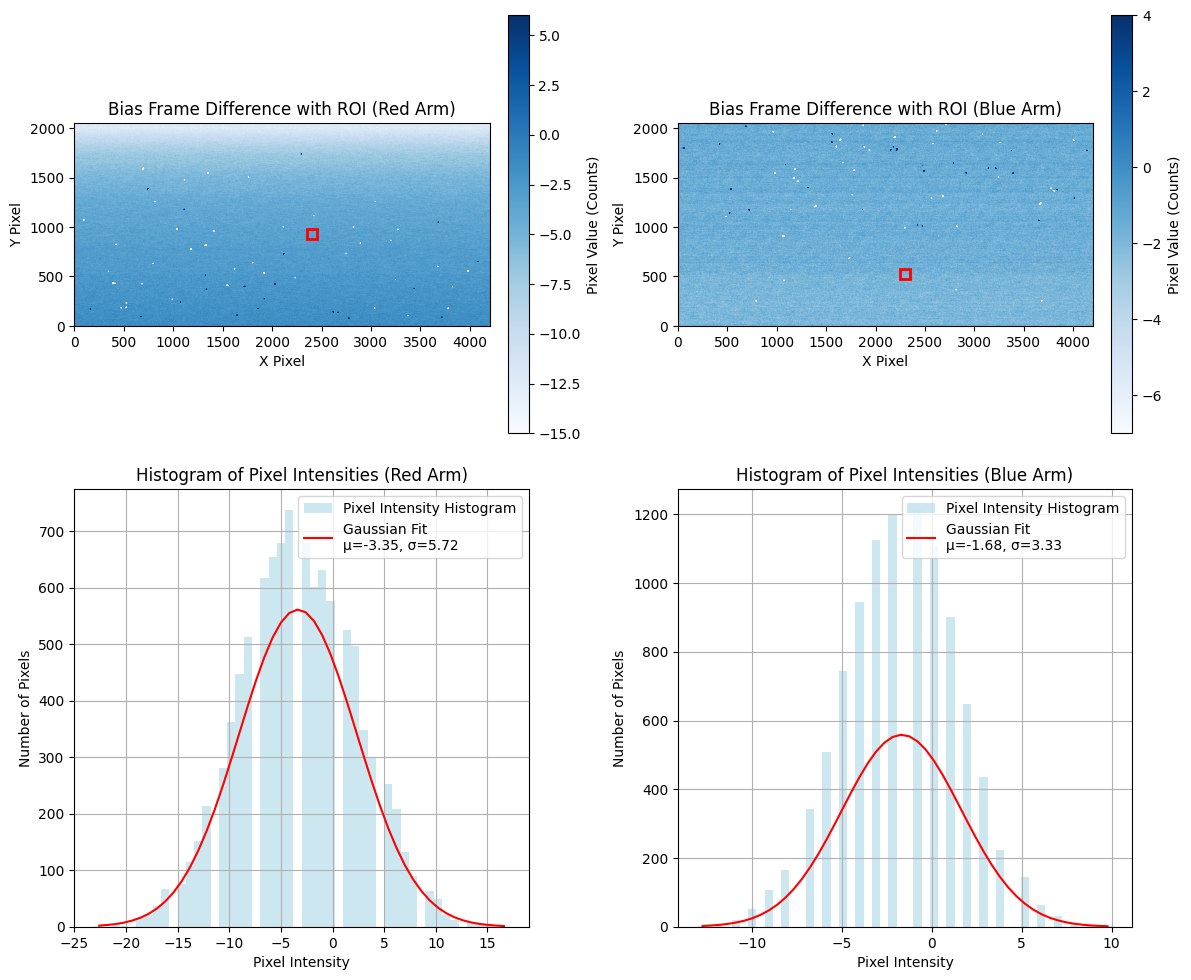

Standard Deviation in Region (Red Arm): 5.59 ADU
Standard Deviation in Region (Blue Arm): 3.21 ADU
Gaussian Fit Parameters for Red Arm: μ=-3.35, σ=5.72
Gaussian Fit Parameters for Blue Arm: μ=-1.68, σ=3.33


In [ ]:
# Define a Gaussian function
def gaussian(x, a, mu, sigma):
    return a * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

# Define region of interest for bias, subtract master bias, calculate standard deviation, and plot side by side
def calculate_stddev_and_plot_roi_with_histograms(bias_file_red_1, bias_file_red_2, bias_file_blue_1, bias_file_blue_2, region_size, red_offset, blue_offset):
    def process_bias_files(bias_file_1, bias_file_2, arm_name, offset_x, offset_y):
        with fits.open(bias_file_1) as hdul1, fits.open(bias_file_2) as hdul2:
            bias_data_1 = np.array(hdul1[0].data, dtype=np.float32)
            bias_data_2 = np.array(hdul2[0].data, dtype=np.float32)

            # Subtract one bias frame from the other
            bias_data_corrected = bias_data_2 - bias_data_1
            print(bias_data_1)
            print(bias_data_2)
            print(bias_data_corrected)
            #print(np.type(bias_data_corrected))

            # Define a square region in the frame with offsets
            center_x, center_y = bias_data_corrected.shape[1] // 2, bias_data_corrected.shape[0] // 2
            region = bias_data_corrected[
                center_y + offset_y - region_size // 2 : center_y + offset_y + region_size // 2,
                center_x + offset_x - region_size // 2 : center_x + offset_x + region_size // 2
            ]

            # Calculate the standard deviation in the region
            region_data1= bias_data_1[
                center_y + offset_y - region_size // 2 : center_y + offset_y + region_size // 2,
                center_x + offset_x - region_size // 2 : center_x + offset_x + region_size // 2
            ]
            region_data2= bias_data_2[
                center_y + offset_y - region_size // 2 : center_y + offset_y + region_size // 2,
                center_x + offset_x - region_size // 2 : center_x + offset_x + region_size // 2
            ]


            stddev = np.std(region)
            stddev1 = np.std(region_data1)
            stddev2 = np.std(region_data2)
            print(f"Standard Deviation in Region (Red Arm): {stddev1:.2f} ADU")
            print(f"Standard Deviation in Region (Blue Arm): {stddev2:.2f} ADU")
            print(f"Standard Deviation (theoretica):l): {np.sqrt(stddev1**2 + stddev2**2):.3f} ADU")
            print(f"Standard Deviation in Region (Combined): {stddev:.2f} ADU")

            # Calculate vmin and vmax using percentiles for better visualization
            vmin = np.percentile(bias_data_corrected, 5)
            vmax = np.percentile(bias_data_corrected, 95)

            return bias_data_corrected, region, stddev, vmin, vmax

    # Process red and blue bias files with their respective offsets
    bias_data_red, region_red, stddev_red, vmin_red, vmax_red = process_bias_files(
        bias_file_red_1, bias_file_red_2, "Red", red_offset[0], red_offset[1]
    )
    bias_data_blue, region_blue, stddev_blue, vmin_blue, vmax_blue = process_bias_files(
        bias_file_blue_1, bias_file_blue_2, "Blue", blue_offset[0], blue_offset[1]
    )

    import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from scipy.optimize import curve_fit
import os

# Define a Gaussian function
def gaussian(x, a, mu, sigma):
    return a * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

# Define region of interest for bias, subtract master bias, calculate standard deviation, and plot side by side
def calculate_stddev_and_plot_roi_with_histograms(bias_file_red_1, bias_file_red_2, bias_file_blue_1, bias_file_blue_2, region_size, red_offset, blue_offset):
    def process_bias_files(bias_file_1, bias_file_2, arm_name, offset_x, offset_y):
        with fits.open(bias_file_1) as hdul1, fits.open(bias_file_2) as hdul2:
            bias_data_1 = np.array(hdul1[0].data, dtype=np.float32)
            bias_data_2 = np.array(hdul2[0].data, dtype=np.float32)

            # Subtract one bias frame from the other
            bias_data_corrected = bias_data_2 - bias_data_1
            print(bias_data_1)
            print(bias_data_2)
            print(bias_data_corrected)
            #print(np.type(bias_data_corrected))

            # Define a square region in the frame with offsets
            center_x, center_y = bias_data_corrected.shape[1] // 2, bias_data_corrected.shape[0] // 2
            region = bias_data_corrected[
                center_y + offset_y - region_size // 2 : center_y + offset_y + region_size // 2,
                center_x + offset_x - region_size // 2 : center_x + offset_x + region_size // 2
            ]

            # Calculate the standard deviation in the region
            region_data1= bias_data_1[
                center_y + offset_y - region_size // 2 : center_y + offset_y + region_size // 2,
                center_x + offset_x - region_size // 2 : center_x + offset_x + region_size // 2
            ]
            region_data2= bias_data_2[
                center_y + offset_y - region_size // 2 : center_y + offset_y + region_size // 2,
                center_x + offset_x - region_size // 2 : center_x + offset_x + region_size // 2
            ]


            stddev = np.std(region)
            stddev1 = np.std(region_data1)
            stddev2 = np.std(region_data2)
            print(f"Standard Deviation in Region (Red Arm): {stddev1:.2f} ADU")
            print(f"Standard Deviation in Region (Blue Arm): {stddev2:.2f} ADU")
            print(f"Standard Deviation (theoretica):l): {np.sqrt(stddev1**2 + stddev2**2):.3f} ADU")
            print(f"Standard Deviation in Region (Combined): {stddev:.2f} ADU")

            # Calculate vmin and vmax using percentiles for better visualization
            vmin = np.percentile(bias_data_corrected, 5)
            vmax = np.percentile(bias_data_corrected, 95)

            return bias_data_corrected, region, stddev, vmin, vmax

    # Process red and blue bias files with their respective offsets
    bias_data_red, region_red, stddev_red, vmin_red, vmax_red = process_bias_files(
        bias_file_red_1, bias_file_red_2, "Red", red_offset[0], red_offset[1]
    )
    bias_data_blue, region_blue, stddev_blue, vmin_blue, vmax_blue = process_bias_files(
        bias_file_blue_1, bias_file_blue_2, "Blue", blue_offset[0], blue_offset[1]
    )

    # Create a 2-row plot: first row for bias frames, second row for histograms
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))  # 2 rows, 2 columns

    # Plot Red Arm Bias Frame
    im_red = axes[0, 0].imshow(bias_data_red, cmap="Blues", origin="lower", vmin=vmin_red, vmax=vmax_red)
    axes[0, 0].set_title("Bias Frame Difference with ROI (Red Arm)", fontsize=12)
    axes[0, 0].set_xlabel("X Pixel", fontsize=10)
    axes[0, 0].set_ylabel("Y Pixel", fontsize=10)
    plt.colorbar(im_red, ax=axes[0, 0], fraction=0.046, pad=0.04, label="Pixel Value (Counts)")

    # Highlight the region of interest for Red Arm
    rect_red = plt.Rectangle(
        (bias_data_red.shape[1] // 2 + red_offset[0] - region_size // 2, bias_data_red.shape[0] // 2 + red_offset[1] - region_size // 2),
        region_size,
        region_size,
        edgecolor="red",
        facecolor="none",
        linewidth=2,
    )
    axes[0, 0].add_patch(rect_red)

    # Plot Blue Arm Bias Frame
    im_blue = axes[0, 1].imshow(bias_data_blue, cmap="Blues", origin="lower", vmin=vmin_blue, vmax=vmax_blue)
    axes[0, 1].set_title("Bias Frame Difference with ROI (Blue Arm)", fontsize=12)
    axes[0, 1].set_xlabel("X Pixel", fontsize=10)
    axes[0, 1].set_ylabel("Y Pixel", fontsize=10)
    plt.colorbar(im_blue, ax=axes[0, 1], fraction=0.046, pad=0.04, label="Pixel Value (Counts)")

    # Highlight the region of interest for Blue Arm
    rect_blue = plt.Rectangle(
        (bias_data_blue.shape[1] // 2 + blue_offset[0] - region_size // 2, bias_data_blue.shape[0] // 2 + blue_offset[1] - region_size // 2),
        region_size,
        region_size,
        edgecolor="red",
        facecolor="none",
        linewidth=2,
    )
    axes[0, 1].add_patch(rect_blue)

    # Plot Red Arm Histogram
    pixel_values_red = region_red.flatten()
    hist_red, bin_edges_red = np.histogram(pixel_values_red, bins=50)
    bin_centers_red = (bin_edges_red[:-1] + bin_edges_red[1:]) / 2
    popt_red, _ = curve_fit(gaussian, bin_centers_red, hist_red, p0=[np.max(hist_red), np.mean(pixel_values_red), np.std(pixel_values_red)])
    axes[1, 0].hist(pixel_values_red, bins=50, alpha=0.6, color="lightblue", label="Pixel Intensity Histogram")
    axes[1, 0].plot(bin_centers_red, gaussian(bin_centers_red, *popt_red), color="red", label=f"Gaussian Fit\nμ={popt_red[1]:.2f}, σ={popt_red[2]:.2f}")
    axes[1, 0].set_title("Histogram of Pixel Intensities (Red Arm)", fontsize=12)
    axes[1, 0].set_xlabel("Pixel Intensity", fontsize=10)
    axes[1, 0].set_ylabel("Number of Pixels", fontsize=10)
    axes[1, 0].legend(fontsize=10)
    axes[1, 0].grid(True)

    # Plot Blue Arm Histogram
    pixel_values_blue = region_blue.flatten()
    hist_blue, bin_edges_blue = np.histogram(pixel_values_blue, bins=50)
    bin_centers_blue = (bin_edges_blue[:-1] + bin_edges_blue[1:]) / 2
    popt_blue, _ = curve_fit(gaussian, bin_centers_blue, hist_blue, p0=[np.max(hist_blue), np.mean(pixel_values_blue), np.std(pixel_values_blue)])
    axes[1, 1].hist(pixel_values_blue, bins=50, alpha=0.6, color="lightblue", label="Pixel Intensity Histogram")
    axes[1, 1].plot(bin_centers_blue, gaussian(bin_centers_blue, *popt_blue), color="red", label=f"Gaussian Fit\nμ={popt_blue[1]:.2f}, σ={popt_blue[2]:.2f}")
    axes[1, 1].set_title("Histogram of Pixel Intensities (Blue Arm)", fontsize=12)
    axes[1, 1].set_xlabel("Pixel Intensity", fontsize=10)
    axes[1, 1].set_ylabel("Number of Pixels", fontsize=10)
    axes[1, 1].legend(fontsize=10)
    axes[1, 1].grid(True)

    # Adjust layout for better spacing
    plt.tight_layout()
    plt.show()

    # Print standard deviation results
    print(f"Standard Deviation in Region (Red Arm): {stddev_red:.2f} ADU")
    print(f"Standard Deviation in Region (Blue Arm): {stddev_blue:.2f} ADU")
    print(f"Gaussian Fit Parameters for Red Arm: μ={popt_red[1]:.2f}, σ={popt_red[2]:.2f}")
    print(f"Gaussian Fit Parameters for Blue Arm: μ={popt_blue[1]:.2f}, σ={popt_blue[2]:.2f}")

    return region_red, region_blue

# Example usage
bias_file_path_red_1 = os.path.join(bias_red_folder, "OBK-709088-WiFeS-Red--UT20250314T230114-7.fits")  # Replace with actual file
bias_file_path_red_2 = os.path.join(bias_red_folder, "OBK-709088-WiFeS-Red--UT20250314T230211-9.fits")  # Replace with actual file
bias_file_path_blue_1 = os.path.join(bias_blue_folder, "OBK-709088-WiFeS-Blue-UT20250314T231436-1.fits")  # Replace with actual file
bias_file_path_blue_2 = os.path.join(bias_blue_folder, "OBK-709088-WiFeS-Blue-UT20250314T230211-9.fits")  # Replace with actual file

# Define offsets for the red and blue arms (x_offset, y_offset)
red_offset = (300, -100)  # Example: move ROI 300 pixels left for red arm
blue_offset = (200, -500)  # Example: move ROI 800 pixels right for blue arm

region_red_run, region_blue_run = calculate_stddev_and_plot_roi_with_histograms(
    bias_file_path_red_1, bias_file_path_red_2, bias_file_path_blue_1, bias_file_path_blue_2, region_size=100, red_offset=red_offset, blue_offset=blue_offset
)

 


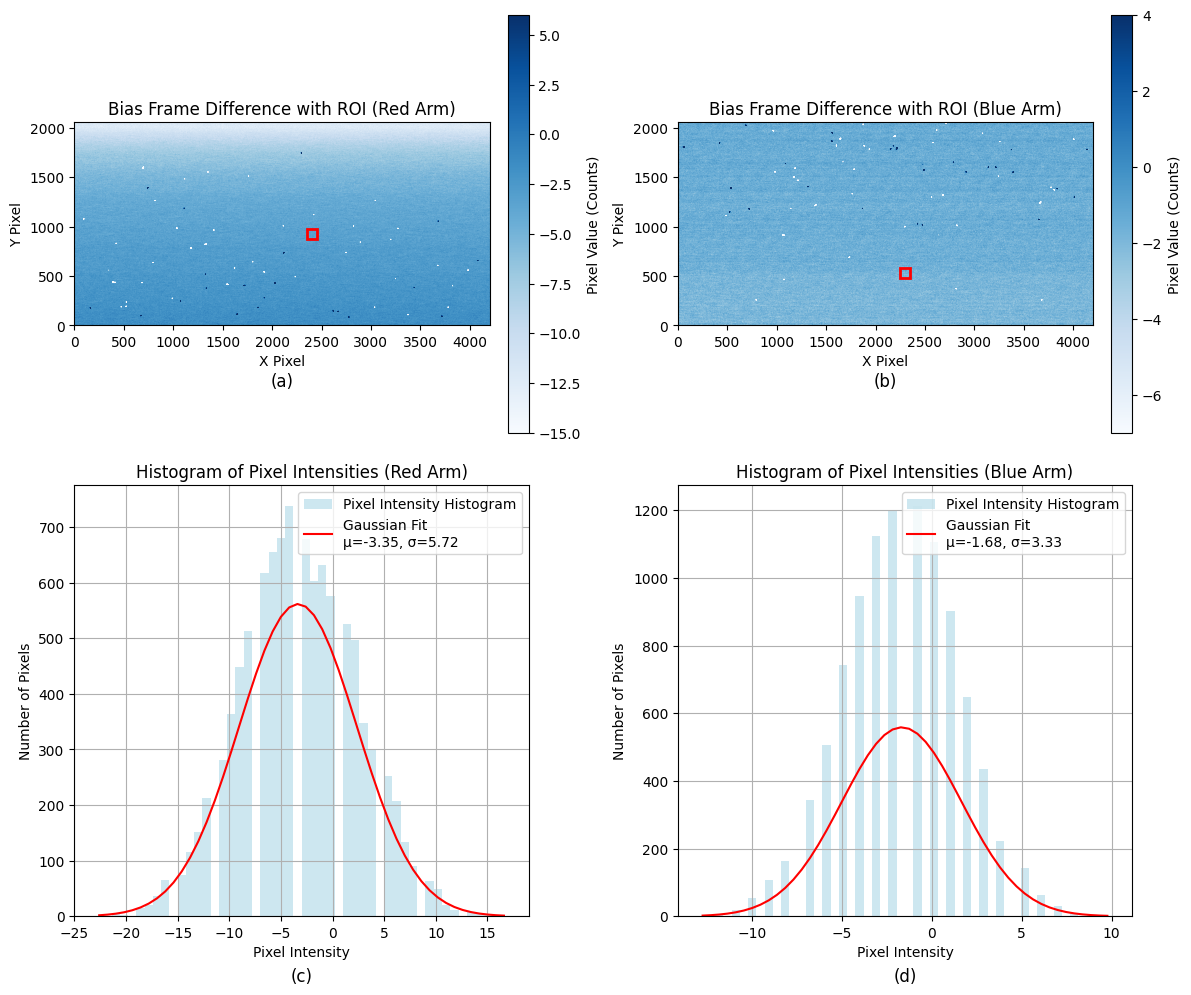

Standard Deviation in Region (Red Arm): 5.59 ADU
Standard Deviation in Region (Blue Arm): 3.21 ADU
Gaussian Fit Parameters for Red Arm: μ=-3.35, σ=5.72
Gaussian Fit Parameters for Blue Arm: μ=-1.68, σ=3.33


In [ ]:
# Define a Gaussian function
def gaussian(x, a, mu, sigma):
    return a * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

# Define region of interest for bias, subtract master bias, calculate standard deviation, and plot side by side
def calculate_stddev_and_plot_roi_with_histograms(bias_file_red_1, bias_file_red_2, bias_file_blue_1, bias_file_blue_2, region_size, red_offset, blue_offset):
    def process_bias_files(bias_file_1, bias_file_2, arm_name, offset_x, offset_y):
        with fits.open(bias_file_1) as hdul1, fits.open(bias_file_2) as hdul2:
            bias_data_1 = np.array(hdul1[0].data, dtype=np.float32)
            bias_data_2 = np.array(hdul2[0].data, dtype=np.float32)

            # Subtract one bias frame from the other
            bias_data_corrected = bias_data_2 - bias_data_1

            # Define a square region in the frame with offsets
            center_x, center_y = bias_data_corrected.shape[1] // 2, bias_data_corrected.shape[0] // 2
            region = bias_data_corrected[
                center_y + offset_y - region_size // 2 : center_y + offset_y + region_size // 2,
                center_x + offset_x - region_size // 2 : center_x + offset_x + region_size // 2
            ]

            # Calculate the standard deviation in the region
            stddev = np.std(region)

            # Calculate vmin and vmax using percentiles for better visualization
            vmin = np.percentile(bias_data_corrected, 5)
            vmax = np.percentile(bias_data_corrected, 95)

            return bias_data_corrected, region, stddev, vmin, vmax

    # Process red and blue bias files with their respective offsets
    bias_data_red, region_red, stddev_red, vmin_red, vmax_red = process_bias_files(
        bias_file_red_1, bias_file_red_2, "Red", red_offset[0], red_offset[1]
    )
    bias_data_blue, region_blue, stddev_blue, vmin_blue, vmax_blue = process_bias_files(
        bias_file_blue_1, bias_file_blue_2, "Blue", blue_offset[0], blue_offset[1]
    )

    # Create a 2-row plot: first row for bias frames, second row for histograms
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))  # 2 rows, 2 columns

    # Plot Red Arm Bias Frame
    im_red = axes[0, 0].imshow(bias_data_red, cmap="Blues", origin="lower", vmin=vmin_red, vmax=vmax_red)
    axes[0, 0].set_title("Bias Frame Difference with ROI (Red Arm)", fontsize=12)
    axes[0, 0].set_xlabel("X Pixel", fontsize=10)
    axes[0, 0].set_ylabel("Y Pixel", fontsize=10)
    plt.colorbar(im_red, ax=axes[0, 0], fraction=0.046, pad=0.04, label="Pixel Value (Counts)")
    axes[0, 0].text(0.5, -0.3, "(a)", transform=axes[0, 0].transAxes, fontsize=12, ha="center")

    # Highlight the region of interest for Red Arm
    rect_red = plt.Rectangle(
        (bias_data_red.shape[1] // 2 + red_offset[0] - region_size // 2, bias_data_red.shape[0] // 2 + red_offset[1] - region_size // 2),
        region_size,
        region_size,
        edgecolor="red",
        facecolor="none",
        linewidth=2,
    )
    axes[0, 0].add_patch(rect_red)

    # Plot Blue Arm Bias Frame
    im_blue = axes[0, 1].imshow(bias_data_blue, cmap="Blues", origin="lower", vmin=vmin_blue, vmax=vmax_blue)
    axes[0, 1].set_title("Bias Frame Difference with ROI (Blue Arm)", fontsize=12)
    axes[0, 1].set_xlabel("X Pixel", fontsize=10)
    axes[0, 1].set_ylabel("Y Pixel", fontsize=10)
    plt.colorbar(im_blue, ax=axes[0, 1], fraction=0.046, pad=0.04, label="Pixel Value (Counts)")
    axes[0, 1].text(0.5, -0.3, "(b)", transform=axes[0, 1].transAxes, fontsize=12, ha="center")

    # Highlight the region of interest for Blue Arm
    rect_blue = plt.Rectangle(
        (bias_data_blue.shape[1] // 2 + blue_offset[0] - region_size // 2, bias_data_blue.shape[0] // 2 + blue_offset[1] - region_size // 2),
        region_size,
        region_size,
        edgecolor="red",
        facecolor="none",
        linewidth=2,
    )
    axes[0, 1].add_patch(rect_blue)

    # Plot Red Arm Histogram
    pixel_values_red = region_red.flatten()
    hist_red, bin_edges_red = np.histogram(pixel_values_red, bins=50)
    bin_centers_red = (bin_edges_red[:-1] + bin_edges_red[1:]) / 2
    popt_red, _ = curve_fit(gaussian, bin_centers_red, hist_red, p0=[np.max(hist_red), np.mean(pixel_values_red), np.std(pixel_values_red)])
    axes[1, 0].hist(pixel_values_red, bins=50, alpha=0.6, color="lightblue", label="Pixel Intensity Histogram")
    axes[1, 0].plot(bin_centers_red, gaussian(bin_centers_red, *popt_red), color="red", label=f"Gaussian Fit\nμ={popt_red[1]:.2f}, σ={popt_red[2]:.2f}")
    axes[1, 0].set_title("Histogram of Pixel Intensities (Red Arm)", fontsize=12)
    axes[1, 0].set_xlabel("Pixel Intensity", fontsize=10)
    axes[1, 0].set_ylabel("Number of Pixels", fontsize=10)
    axes[1, 0].legend(fontsize=10)
    axes[1, 0].grid(True)
    axes[1, 0].text(0.5, -0.15, "(c)", transform=axes[1, 0].transAxes, fontsize=12, ha="center")

    # Plot Blue Arm Histogram
    pixel_values_blue = region_blue.flatten()
    hist_blue, bin_edges_blue = np.histogram(pixel_values_blue, bins=50)
    bin_centers_blue = (bin_edges_blue[:-1] + bin_edges_blue[1:]) / 2
    popt_blue, _ = curve_fit(gaussian, bin_centers_blue, hist_blue, p0=[np.max(hist_blue), np.mean(pixel_values_blue), np.std(pixel_values_blue)])
    axes[1, 1].hist(pixel_values_blue, bins=50, alpha=0.6, color="lightblue", label="Pixel Intensity Histogram")
    axes[1, 1].plot(bin_centers_blue, gaussian(bin_centers_blue, *popt_blue), color="red", label=f"Gaussian Fit\nμ={popt_blue[1]:.2f}, σ={popt_blue[2]:.2f}")
    axes[1, 1].set_title("Histogram of Pixel Intensities (Blue Arm)", fontsize=12)
    axes[1, 1].set_xlabel("Pixel Intensity", fontsize=10)
    axes[1, 1].set_ylabel("Number of Pixels", fontsize=10)
    axes[1, 1].legend(fontsize=10)
    axes[1, 1].grid(True)
    axes[1, 1].text(0.5, -0.15, "(d)", transform=axes[1, 1].transAxes, fontsize=12, ha="center")

    # Adjust layout for better spacing
    plt.tight_layout()
    plt.show()

    # Print standard deviation results
    print(f"Standard Deviation in Region (Red Arm): {stddev_red:.2f} ADU")
    print(f"Standard Deviation in Region (Blue Arm): {stddev_blue:.2f} ADU")
    print(f"Gaussian Fit Parameters for Red Arm: μ={popt_red[1]:.2f}, σ={popt_red[2]:.2f}")
    print(f"Gaussian Fit Parameters for Blue Arm: μ={popt_blue[1]:.2f}, σ={popt_blue[2]:.2f}")

    return region_red, region_blue

# Example usage
bias_file_path_red_1 = os.path.join(bias_red_folder, "OBK-709088-WiFeS-Red--UT20250314T230114-7.fits")  # Replace with actual file
bias_file_path_red_2 = os.path.join(bias_red_folder, "OBK-709088-WiFeS-Red--UT20250314T230211-9.fits")  # Replace with actual file
bias_file_path_blue_1 = os.path.join(bias_blue_folder, "OBK-709088-WiFeS-Blue-UT20250314T231436-1.fits")  # Replace with actual file
bias_file_path_blue_2 = os.path.join(bias_blue_folder, "OBK-709088-WiFeS-Blue-UT20250314T230211-9.fits")  # Replace with actual file

# Define offsets for the red and blue arms (x_offset, y_offset)
red_offset = (300, -100)  # Example: move ROI 300 pixels left for red arm
blue_offset = (200, -500)  # Example: move ROI 800 pixels right for blue arm

region_red_run, region_blue_run = calculate_stddev_and_plot_roi_with_histograms(
    bias_file_path_red_1, bias_file_path_red_2, bias_file_path_blue_1, bias_file_path_blue_2, region_size=100, red_offset=red_offset, blue_offset=blue_offset
)

In [ ]:
def find_flat_fields_with_same_exptime(flat_folder):
    # Dictionary to store files grouped by exposure time
    exptime_dict = {}

    # Iterate through all FITS files in the folder
    for filename in os.listdir(flat_folder):
        if filename.lower().endswith(".fits"):
            file_path = os.path.join(flat_folder, filename)
            try:
                # Open the FITS file and read the header
                with fits.open(file_path) as hdul:
                    header = hdul[0].header
                    exptime = header.get("EXPTIME", None)  # Get the exposure time from the header

                    if exptime is not None:
                        # Group files by exposure time
                        if exptime not in exptime_dict:
                            exptime_dict[exptime] = []
                        exptime_dict[exptime].append(file_path)
            except Exception as e:
                print(f"Error reading {filename}: {e}")

    # Find two files with the same exposure time
    for exptime, files in exptime_dict.items():
        if len(files) >= 2:
            print(f"Found two flat fields with EXPTIME={exptime}:")
            print(f"  File 1: {files[0]}")
            print(f"  File 2: {files[1]}")
            return files[0], files[1]

    print("No two flat fields with the same exposure time were found.")
    return None, None

# Example usage
flat_folder_red = "/Users/Ishfahanirusyda/Documents/Obstech/BiasFlats/FLATS/Red"  # Replace with the path to your flat folder
file1_red, file2_red = find_flat_fields_with_same_exptime(flat_folder_red)
flat_folder_blue = "/Users/Ishfahanirusyda/Documents/Obstech/BiasFlats/FLATS/Blue"  # Replace with the path to your flat folder
file1_blue, file2_blue = find_flat_fields_with_same_exptime(flat_folder_blue)

Found two flat fields with EXPTIME=2.5:
  File 1: /Users/Ishfahanirusyda/Documents/Obstech/BiasFlats/FLATS/Red/OBK-709344-WiFeS-Red--UT20250315T000118-1.fits
  File 2: /Users/Ishfahanirusyda/Documents/Obstech/BiasFlats/FLATS/Red/OBK-709344-WiFeS-Red--UT20250315T000426-4.fits
Found two flat fields with EXPTIME=30.0:
  File 1: /Users/Ishfahanirusyda/Documents/Obstech/BiasFlats/FLATS/Blue/OBK-709440-WiFeS-Blue-UT20250315T000744-7.fits
  File 2: /Users/Ishfahanirusyda/Documents/Obstech/BiasFlats/FLATS/Blue/OBK-709440-WiFeS-Blue-UT20250315T000605-6.fits


## Question 5

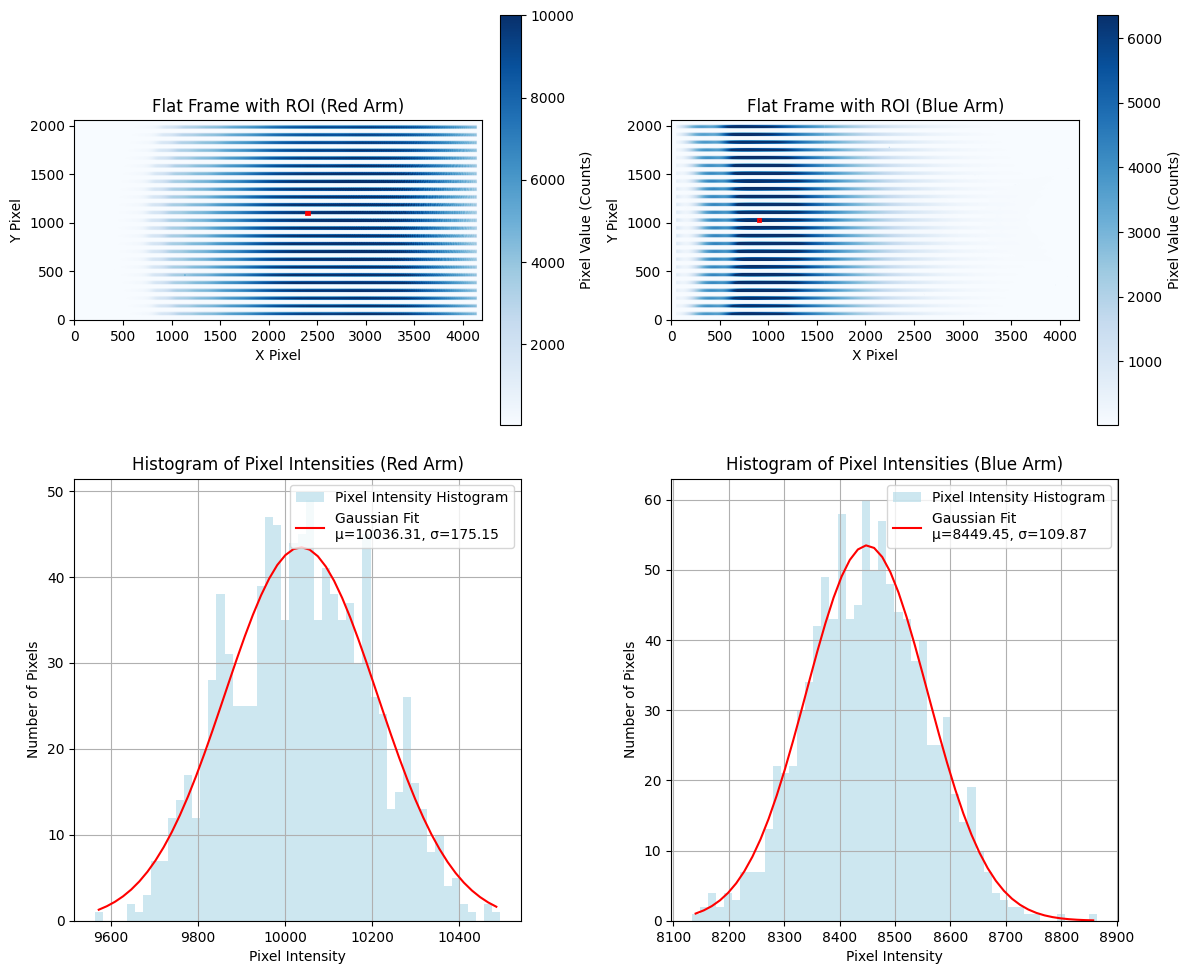

Standard Deviation in Region (Red Arm): 161.49 ADU
Standard Deviation in Region (Blue Arm): 107.68 ADU
Gaussian Fit Parameters for Red Arm: μ=10036.31, σ=175.15
Gaussian Fit Parameters for Blue Arm: μ=8449.45, σ=109.87


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from scipy.optimize import curve_fit
import os

# Define a Gaussian function
def gaussian(x, a, mu, sigma):
    return a * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

# Define region of interest for flat fields, subtract master bias, calculate standard deviation, and plot side by side
def calculate_stddev_and_plot_roi_with_histograms(flat_file_red, flat_file_blue, master_bias_red, master_bias_blue, region_size, red_offset, blue_offset):
    def process_flat_file(flat_file, master_bias, arm_name, offset_x, offset_y):
        with fits.open(flat_file) as hdul:
            flat_data = hdul[0].data

            # Subtract the master bias
            flat_data_corrected = flat_data - master_bias
            region_width = 50  # Width of the rectangular region
            region_height = 20  # Height of the rectangular region

            # Define a square region in the frame with offsets
            center_x, center_y = flat_data_corrected.shape[1] // 2, flat_data_corrected.shape[0] // 2
            region = flat_data_corrected[
                center_y + offset_y - region_height // 2 : center_y + offset_y + region_height // 2,
                center_x + offset_x - region_width // 2 : center_x + offset_x + region_width // 2
            ]

            # Calculate the standard deviation in the region
            stddev = np.std(region)

            # Calculate vmin and vmax using percentiles for better visualization
            vmin = np.percentile(flat_data_corrected, 5)
            vmax = np.percentile(flat_data_corrected, 95)

            return flat_data_corrected, region, stddev, vmin, vmax

    # Process red and blue flat files with their respective offsets
    flat_data_red, region_red, stddev_red, vmin_red, vmax_red = process_flat_file(
        flat_file_red, master_bias_red, "Red", red_offset[0], red_offset[1]
    )
    flat_data_blue, region_blue, stddev_blue, vmin_blue, vmax_blue = process_flat_file(
        flat_file_blue, master_bias_blue, "Blue", blue_offset[0], blue_offset[1]
    )

    # Create a 2-row plot: first row for flat frames, second row for histograms
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))  # 2 rows, 2 columns

    # Plot Red Arm Flat Frame
    im_red = axes[0, 0].imshow(flat_data_red, cmap="Blues", origin="lower", vmin=vmin_red, vmax=vmax_red)
    axes[0, 0].set_title("Flat Frame with ROI (Red Arm)", fontsize=12)
    axes[0, 0].set_xlabel("X Pixel", fontsize=10)
    axes[0, 0].set_ylabel("Y Pixel", fontsize=10)
    plt.colorbar(im_red, ax=axes[0, 0], fraction=0.046, pad=0.04, label="Pixel Value (Counts)")

    # Highlight the region of interest for Red Arm
    rect_red = plt.Rectangle(
        (flat_data_red.shape[1] // 2 + red_offset[0] - region_size // 2, flat_data_red.shape[0] // 2 + red_offset[1] - region_size // 2),
        region_size,
        region_size,
        edgecolor="red",
        facecolor="none",
        linewidth=2,
    )
    axes[0, 0].add_patch(rect_red)

    # Plot Blue Arm Flat Frame
    im_blue = axes[0, 1].imshow(flat_data_blue, cmap="Blues", origin="lower", vmin=vmin_blue, vmax=vmax_blue)
    axes[0, 1].set_title("Flat Frame with ROI (Blue Arm)", fontsize=12)
    axes[0, 1].set_xlabel("X Pixel", fontsize=10)
    axes[0, 1].set_ylabel("Y Pixel", fontsize=10)
    plt.colorbar(im_blue, ax=axes[0, 1], fraction=0.046, pad=0.04, label="Pixel Value (Counts)")

    # Highlight the region of interest for Blue Arm
    rect_blue = plt.Rectangle(
        (flat_data_blue.shape[1] // 2 + blue_offset[0] - region_size // 2, flat_data_blue.shape[0] // 2 + blue_offset[1] - region_size // 2),
        region_size,
        region_size,
        edgecolor="red",
        facecolor="none",
        linewidth=2,
    )
    axes[0, 1].add_patch(rect_blue)

    # Plot Red Arm Histogram
    pixel_values_red = region_red.flatten()
    hist_red, bin_edges_red = np.histogram(pixel_values_red, bins=50)
    bin_centers_red = (bin_edges_red[:-1] + bin_edges_red[1:]) / 2
    popt_red, _ = curve_fit(gaussian, bin_centers_red, hist_red, p0=[np.max(hist_red), np.mean(pixel_values_red), np.std(pixel_values_red)])
    axes[1, 0].hist(pixel_values_red, bins=50, alpha=0.6, color="lightblue", label="Pixel Intensity Histogram")
    axes[1, 0].plot(bin_centers_red, gaussian(bin_centers_red, *popt_red), color="red", label=f"Gaussian Fit\nμ={popt_red[1]:.2f}, σ={popt_red[2]:.2f}")
    axes[1, 0].set_title("Histogram of Pixel Intensities (Red Arm)", fontsize=12)
    axes[1, 0].set_xlabel("Pixel Intensity", fontsize=10)
    axes[1, 0].set_ylabel("Number of Pixels", fontsize=10)
    axes[1, 0].legend(fontsize=10)
    axes[1, 0].grid(True)

    # Plot Blue Arm Histogram
    pixel_values_blue = region_blue.flatten()
    hist_blue, bin_edges_blue = np.histogram(pixel_values_blue, bins=50)
    bin_centers_blue = (bin_edges_blue[:-1] + bin_edges_blue[1:]) / 2
    popt_blue, _ = curve_fit(gaussian, bin_centers_blue, hist_blue, p0=[np.max(hist_blue), np.mean(pixel_values_blue), np.std(pixel_values_blue)])
    axes[1, 1].hist(pixel_values_blue, bins=50, alpha=0.6, color="lightblue", label="Pixel Intensity Histogram")
    axes[1, 1].plot(bin_centers_blue, gaussian(bin_centers_blue, *popt_blue), color="red", label=f"Gaussian Fit\nμ={popt_blue[1]:.2f}, σ={popt_blue[2]:.2f}")
    axes[1, 1].set_title("Histogram of Pixel Intensities (Blue Arm)", fontsize=12)
    axes[1, 1].set_xlabel("Pixel Intensity", fontsize=10)
    axes[1, 1].set_ylabel("Number of Pixels", fontsize=10)
    axes[1, 1].legend(fontsize=10)
    axes[1, 1].grid(True)

    # Adjust layout for better spacing
    plt.tight_layout()
    plt.show()

    # Print standard deviation results
    print(f"Standard Deviation in Region (Red Arm): {stddev_red:.2f} ADU")
    print(f"Standard Deviation in Region (Blue Arm): {stddev_blue:.2f} ADU")
    print(f"Gaussian Fit Parameters for Red Arm: μ={popt_red[1]:.2f}, σ={popt_red[2]:.2f}")
    print(f"Gaussian Fit Parameters for Blue Arm: μ={popt_blue[1]:.2f}, σ={popt_blue[2]:.2f}")

    return region_red, region_blue

# Example usage
flat_file_path_red = '/Users/Ishfahanirusyda/Documents/Obstech/BiasFlats/FLATS/Red/OBK-709344-WiFeS-Red--UT20250315T000118-1.fits'
flat_file_path_blue = '/Users/Ishfahanirusyda/Documents/Obstech/BiasFlats/FLATS/Blue/OBK-709440-WiFeS-Blue-UT20250315T000744-7.fits'

# Define offsets for the red and blue arms (x_offset, y_offset)
red_offset = (300, 74)  # Example: move ROI 300 pixels left for red arm
blue_offset = (-1200, 0)  # Example: move ROI 800 pixels right for blue arm

region_red_run, region_blue_run = calculate_stddev_and_plot_roi_with_histograms(
    flat_file_path_red, flat_file_path_blue, master_bias_red, master_bias_blue, region_size=25, red_offset=red_offset, blue_offset=blue_offset
)

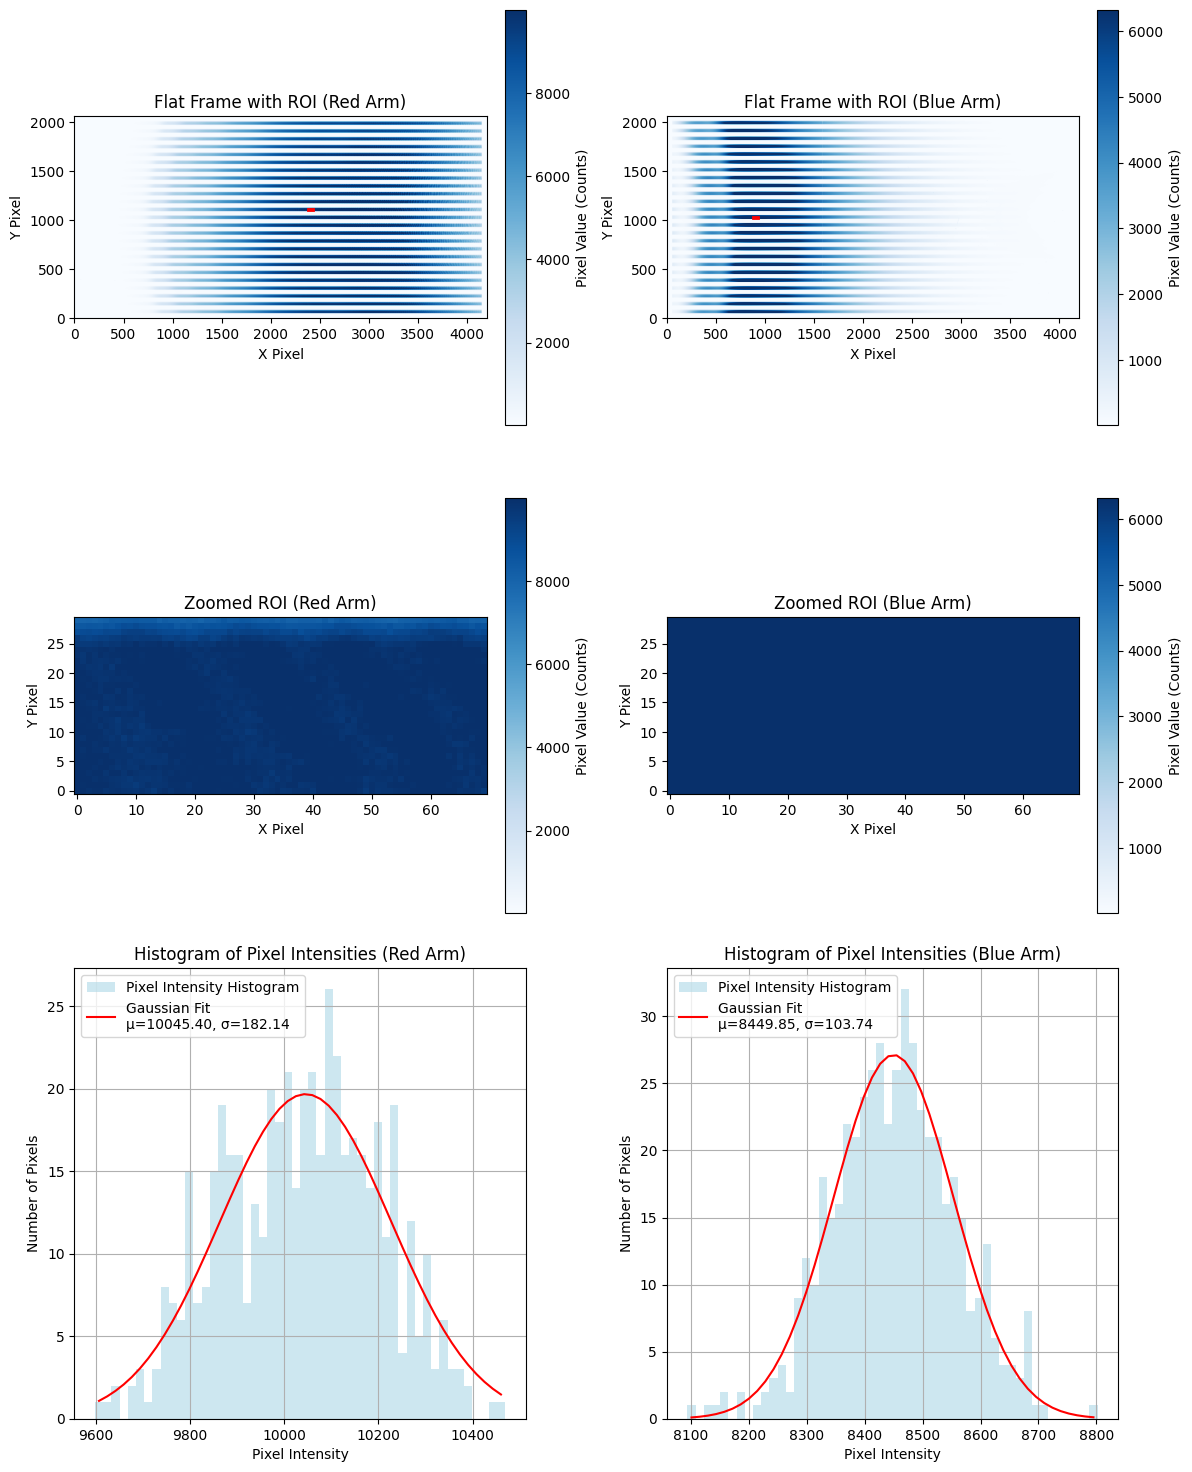

Standard Deviation in Region (Red Arm): 164.85 ADU
Standard Deviation in Region (Blue Arm): 105.52 ADU
Gaussian Fit Parameters for Red Arm: μ=10045.40, σ=182.14
Gaussian Fit Parameters for Blue Arm: μ=8449.85, σ=103.74


In [ ]:
# Define region of interest for flat fields, subtract master bias, calculate standard deviation, and plot side by side
def calculate_stddev_and_plot_roi_with_histograms(flat_file_red, flat_file_blue, master_bias_red, master_bias_blue, region_width, region_height, red_offset, blue_offset):
    def process_flat_file(flat_file, master_bias, arm_name, offset_x, offset_y):
        with fits.open(flat_file) as hdul:
            flat_data = hdul[0].data

            # Subtract the master bias
            flat_data_corrected = flat_data - master_bias

            # Define a rectangular region in the frame with offsets
            center_x, center_y = flat_data_corrected.shape[1] // 2, flat_data_corrected.shape[0] // 2
            region = flat_data_corrected[
                center_y + offset_y - region_height // 2 : center_y + offset_y + region_height // 2,
                center_x + offset_x - region_width // 2 : center_x + offset_x + region_width // 2
            ]

            # Calculate the standard deviation in the region
            stddev = np.std(region)

            # Calculate vmin and vmax using percentiles for better visualization
            vmin = np.percentile(flat_data_corrected, 5)
            vmax = np.percentile(flat_data_corrected, 95)

            return flat_data_corrected, region, stddev, vmin, vmax

    # Process red and blue flat files with their respective offsets
    flat_data_red, region_red, stddev_red, vmin_red, vmax_red = process_flat_file(
        flat_file_red, master_bias_red, "Red", red_offset[0], red_offset[1]
    )
    flat_data_blue, region_blue, stddev_blue, vmin_blue, vmax_blue = process_flat_file(
        flat_file_blue, master_bias_blue, "Blue", blue_offset[0], blue_offset[1]
    )

    # Create a 3-row plot: first row for flat frames, second row for zoomed ROI, third row for histograms
    fig, axes = plt.subplots(3, 2, figsize=(12, 15))  # 3 rows, 2 columns

    # Plot Red Arm Flat Frame
    im_red = axes[0, 0].imshow(flat_data_red, cmap="Blues", origin="lower", vmin=vmin_red, vmax=vmax_red)
    axes[0, 0].set_title("Flat Frame with ROI (Red Arm)", fontsize=12)
    axes[0, 0].set_xlabel("X Pixel", fontsize=10)
    axes[0, 0].set_ylabel("Y Pixel", fontsize=10)
    plt.colorbar(im_red, ax=axes[0, 0], fraction=0.046, pad=0.04, label="Pixel Value (Counts)")

    # Highlight the region of interest for Red Arm
    rect_red = plt.Rectangle(
        (flat_data_red.shape[1] // 2 + red_offset[0] - region_width // 2, flat_data_red.shape[0] // 2 + red_offset[1] - region_height // 2),
        region_width,
        region_height,
        edgecolor="red",
        facecolor="none",
        linewidth=2,
    )
    axes[0, 0].add_patch(rect_red)

    # Plot Blue Arm Flat Frame
    im_blue = axes[0, 1].imshow(flat_data_blue, cmap="Blues", origin="lower", vmin=vmin_blue, vmax=vmax_blue)
    axes[0, 1].set_title("Flat Frame with ROI (Blue Arm)", fontsize=12)
    axes[0, 1].set_xlabel("X Pixel", fontsize=10)
    axes[0, 1].set_ylabel("Y Pixel", fontsize=10)
    plt.colorbar(im_blue, ax=axes[0, 1], fraction=0.046, pad=0.04, label="Pixel Value (Counts)")

    # Highlight the region of interest for Blue Arm
    rect_blue = plt.Rectangle(
        (flat_data_blue.shape[1] // 2 + blue_offset[0] - region_width // 2, flat_data_blue.shape[0] // 2 + blue_offset[1] - region_height // 2),
        region_width,
        region_height,
        edgecolor="red",
        facecolor="none",
        linewidth=2,
    )
    axes[0, 1].add_patch(rect_blue)

    # Plot Zoomed ROI for Red Arm
    zoom_margin = 10  # Add margin around the ROI for better context
    zoomed_region_red = flat_data_red[
        flat_data_red.shape[0] // 2 + red_offset[1] - region_height // 2 - zoom_margin : flat_data_red.shape[0] // 2 + red_offset[1] + region_height // 2 + zoom_margin,
        flat_data_red.shape[1] // 2 + red_offset[0] - region_width // 2 - zoom_margin : flat_data_red.shape[1] // 2 + red_offset[0] + region_width // 2 + zoom_margin
    ]
    im_zoom_red = axes[1, 0].imshow(zoomed_region_red, cmap="Blues", origin="lower", vmin=vmin_red, vmax=vmax_red)
    axes[1, 0].set_title("Zoomed ROI (Red Arm)", fontsize=12)
    axes[1, 0].set_xlabel("X Pixel", fontsize=10)
    axes[1, 0].set_ylabel("Y Pixel", fontsize=10)
    plt.colorbar(im_zoom_red, ax=axes[1, 0], fraction=0.046, pad=0.04, label="Pixel Value (Counts)")

    # Plot Zoomed ROI for Blue Arm
    zoomed_region_blue = flat_data_blue[
        flat_data_blue.shape[0] // 2 + blue_offset[1] - region_height // 2 - zoom_margin : flat_data_blue.shape[0] // 2 + blue_offset[1] + region_height // 2 + zoom_margin,
        flat_data_blue.shape[1] // 2 + blue_offset[0] - region_width // 2 - zoom_margin : flat_data_blue.shape[1] // 2 + blue_offset[0] + region_width // 2 + zoom_margin
    ]
    im_zoom_blue = axes[1, 1].imshow(zoomed_region_blue, cmap="Blues", origin="lower", vmin=vmin_blue, vmax=vmax_blue)
    axes[1, 1].set_title("Zoomed ROI (Blue Arm)", fontsize=12)
    axes[1, 1].set_xlabel("X Pixel", fontsize=10)
    axes[1, 1].set_ylabel("Y Pixel", fontsize=10)
    plt.colorbar(im_zoom_blue, ax=axes[1, 1], fraction=0.046, pad=0.04, label="Pixel Value (Counts)")

    # Plot Red Arm Histogram
    pixel_values_red = region_red.flatten()
    hist_red, bin_edges_red = np.histogram(pixel_values_red, bins=50)
    bin_centers_red = (bin_edges_red[:-1] + bin_edges_red[1:]) / 2
    popt_red, _ = curve_fit(gaussian, bin_centers_red, hist_red, p0=[np.max(hist_red), np.mean(pixel_values_red), np.std(pixel_values_red)])
    axes[2, 0].hist(pixel_values_red, bins=50, alpha=0.6, color="lightblue", label="Pixel Intensity Histogram")
    axes[2, 0].plot(bin_centers_red, gaussian(bin_centers_red, *popt_red), color="red", label=f"Gaussian Fit\nμ={popt_red[1]:.2f}, σ={popt_red[2]:.2f}")
    axes[2, 0].set_title("Histogram of Pixel Intensities (Red Arm)", fontsize=12)
    axes[2, 0].set_xlabel("Pixel Intensity", fontsize=10)
    axes[2, 0].set_ylabel("Number of Pixels", fontsize=10)
    axes[2, 0].legend(fontsize=10)
    axes[2, 0].grid(True)

    # Plot Blue Arm Histogram
    pixel_values_blue = region_blue.flatten()
    hist_blue, bin_edges_blue = np.histogram(pixel_values_blue, bins=50)
    bin_centers_blue = (bin_edges_blue[:-1] + bin_edges_blue[1:]) / 2
    popt_blue, _ = curve_fit(gaussian, bin_centers_blue, hist_blue, p0=[np.max(hist_blue), np.mean(pixel_values_blue), np.std(pixel_values_blue)])
    axes[2, 1].hist(pixel_values_blue, bins=50, alpha=0.6, color="lightblue", label="Pixel Intensity Histogram")
    axes[2, 1].plot(bin_centers_blue, gaussian(bin_centers_blue, *popt_blue), color="red", label=f"Gaussian Fit\nμ={popt_blue[1]:.2f}, σ={popt_blue[2]:.2f}")
    axes[2, 1].set_title("Histogram of Pixel Intensities (Blue Arm)", fontsize=12)
    axes[2, 1].set_xlabel("Pixel Intensity", fontsize=10)
    axes[2, 1].set_ylabel("Number of Pixels", fontsize=10)
    axes[2, 1].legend(fontsize=10)
    axes[2, 1].grid(True)

    # Adjust layout for better spacing
    plt.tight_layout()
    plt.show()

    # Print standard deviation results
    print(f"Standard Deviation in Region (Red Arm): {stddev_red:.2f} ADU")
    print(f"Standard Deviation in Region (Blue Arm): {stddev_blue:.2f} ADU")
    print(f"Gaussian Fit Parameters for Red Arm: μ={popt_red[1]:.2f}, σ={popt_red[2]:.2f}")
    print(f"Gaussian Fit Parameters for Blue Arm: μ={popt_blue[1]:.2f}, σ={popt_blue[2]:.2f}")

    return region_red, region_blue

# Example usage
#flat_file_path_red = '/Users/Ishfahanirusyda/Documents/Obstech/BiasFlats/FLATS/Red/OBK-709344-WiFeS-Red--UT20250315T000118-1.fits'
#flat_file_path_blue = '/Users/Ishfahanirusyda/Documents/Obstech/BiasFlats/FLATS/Blue/OBK-709440-WiFeS-Blue-UT20250315T000744-7.fits'

# Paths to the flat fields
flat_file_red_1 = "/Users/Ishfahanirusyda/Documents/Obstech/BiasFlats/FLATS/Red/OBK-709344-WiFeS-Red--UT20250315T000118-1.fits"
flat_file_red_2 = "/Users/Ishfahanirusyda/Documents/Obstech/BiasFlats/FLATS/Red/OBK-709344-WiFeS-Red--UT20250315T000426-4.fits"
flat_file_blue_1 = "/Users/Ishfahanirusyda/Documents/Obstech/BiasFlats/FLATS/Blue/OBK-709440-WiFeS-Blue-UT20250315T000744-7.fits"
flat_file_blue_2 = "/Users/Ishfahanirusyda/Documents/Obstech/BiasFlats/FLATS/Blue/OBK-709440-WiFeS-Blue-UT20250315T000605-6.fits"

# Define offsets for the red and blue arms (x_offset, y_offset)
red_offset = (300, 77)  # Example: move ROI 300 pixels left for red arm
blue_offset = (-1200, 0)  # Example: move ROI 800 pixels right for blue arm

region_red_run, region_blue_run = calculate_stddev_and_plot_roi_with_histograms(
    flat_file_red_2, flat_file_blue_2, master_bias_red, master_bias_blue, region_width=50, region_height=10, red_offset=red_offset, blue_offset=blue_offset
)

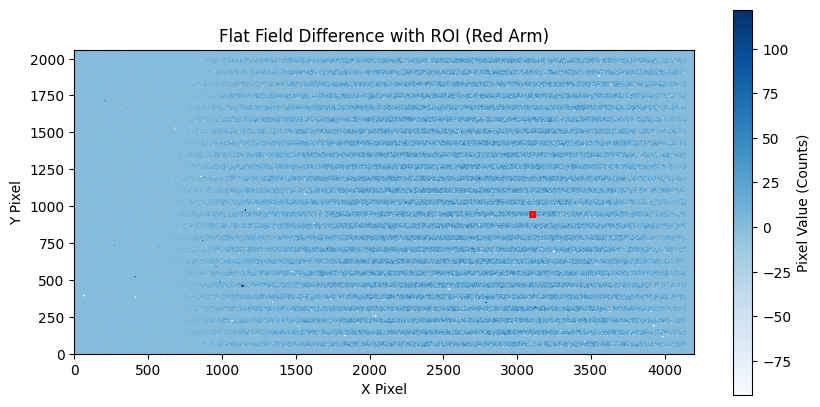

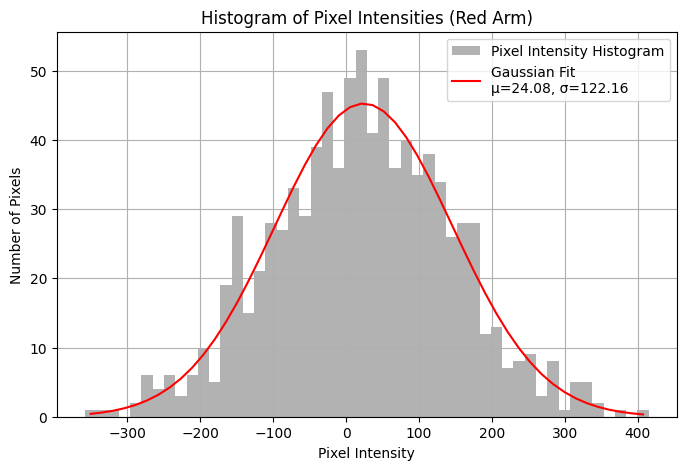

Standard Deviation in Region (Red Arm): 123.63 ADU
Gaussian Fit Parameters for Red Arm: μ=24.08, σ=122.16


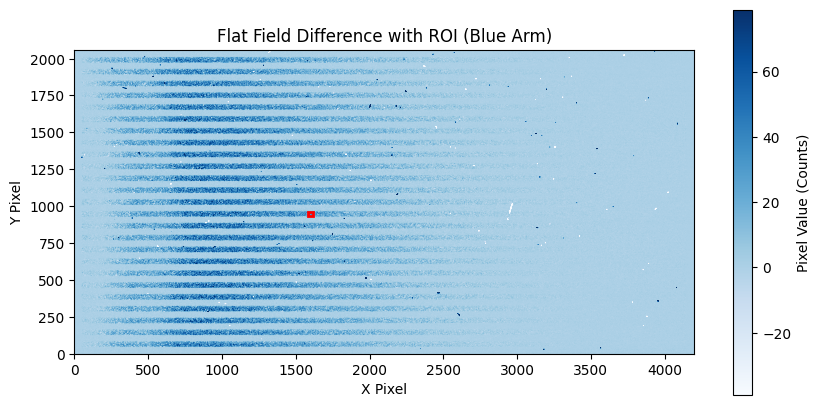

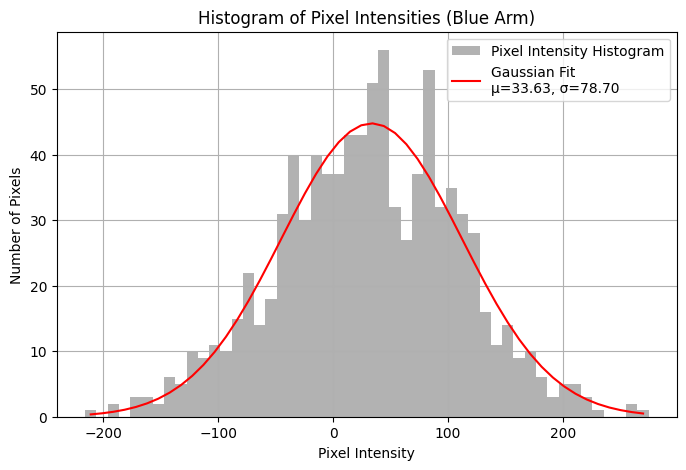

Standard Deviation in Region (Blue Arm): 78.56 ADU
Gaussian Fit Parameters for Blue Arm: μ=33.63, σ=78.70


In [ ]:
# Function to process flat fields, subtract master bias, subtract one from the other, and analyze the ROI
def process_and_analyze_flat_fields(flat_file_1, flat_file_2, master_bias, region_size, offset_x, offset_y, arm_name):
    with fits.open(flat_file_1) as hdul1, fits.open(flat_file_2) as hdul2:
        flat_data_1 = hdul1[0].data - master_bias  # Subtract master bias from the first flat
        flat_data_2 = hdul2[0].data - master_bias  # Subtract master bias from the second flat

        # Subtract one flat field from the other
        flat_data_diff = flat_data_1 - flat_data_2

        # Define a square region in the frame with offsets
        center_x, center_y = flat_data_diff.shape[1] // 2, flat_data_diff.shape[0] // 2
        region = flat_data_diff[
            center_y + offset_y - region_size // 2 : center_y + offset_y + region_size // 2,
            center_x + offset_x - region_size // 2 : center_x + offset_x + region_size // 2
        ]

        # Calculate the standard deviation in the region
        stddev = np.std(region)

        # Calculate vmin and vmax using percentiles for better visualization
        vmin = np.percentile(flat_data_diff, 5)
        vmax = np.percentile(flat_data_diff, 95)

        # Plot the flat field difference with ROI
        plt.figure(figsize=(10, 5))
        plt.imshow(flat_data_diff, cmap="Blues", origin="lower", vmin=vmin, vmax=vmax)
        plt.title(f"Flat Field Difference with ROI ({arm_name} Arm)", fontsize=12)
        plt.xlabel("X Pixel", fontsize=10)
        plt.ylabel("Y Pixel", fontsize=10)
        plt.colorbar(label="Pixel Value (Counts)")

        # Highlight the region of interest
        rect = plt.Rectangle(
            (center_x + offset_x - region_size // 2, center_y + offset_y - region_size // 2),
            region_size,
            region_size,
            edgecolor="red",
            facecolor="none",
            linewidth=2,
        )
        plt.gca().add_patch(rect)
        plt.show()

        # Plot the histogram of the ROI with Gaussian fit
        pixel_values = region.flatten()
        hist, bin_edges = np.histogram(pixel_values, bins=50)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        popt, _ = curve_fit(gaussian, bin_centers, hist, p0=[np.max(hist), np.mean(pixel_values), np.std(pixel_values)])

        plt.figure(figsize=(8, 5))
        plt.hist(pixel_values, bins=50, alpha=0.6, color="gray", label="Pixel Intensity Histogram")
        plt.plot(bin_centers, gaussian(bin_centers, *popt), color="red", label=f"Gaussian Fit\nμ={popt[1]:.2f}, σ={popt[2]:.2f}")
        plt.title(f"Histogram of Pixel Intensities ({arm_name} Arm)", fontsize=12)
        plt.xlabel("Pixel Intensity", fontsize=10)
        plt.ylabel("Number of Pixels", fontsize=10)
        plt.legend(fontsize=10)
        plt.grid(True)
        plt.show()

        # Print the standard deviation and Gaussian fit parameters
        print(f"Standard Deviation in Region ({arm_name} Arm): {stddev:.2f} ADU")
        print(f"Gaussian Fit Parameters for {arm_name} Arm: μ={popt[1]:.2f}, σ={popt[2]:.2f}")

# Example usage
# Paths to the flat fields
flat_file_red_1 = "/Users/Ishfahanirusyda/Documents/Obstech/BiasFlats/FLATS/Red/OBK-709344-WiFeS-Red--UT20250315T000118-1.fits"
flat_file_red_2 = "/Users/Ishfahanirusyda/Documents/Obstech/BiasFlats/FLATS/Red/OBK-709344-WiFeS-Red--UT20250315T000426-4.fits"
flat_file_blue_1 = "/Users/Ishfahanirusyda/Documents/Obstech/BiasFlats/FLATS/Blue/OBK-709440-WiFeS-Blue-UT20250315T000744-7.fits"
flat_file_blue_2 = "/Users/Ishfahanirusyda/Documents/Obstech/BiasFlats/FLATS/Blue/OBK-709440-WiFeS-Blue-UT20250315T000605-6.fits"

# Paths to the master biases
master_bias_red_path = "/Users/Ishfahanirusyda/Documents/Obstech/BiasFlats/BIAS/Red/master_bias_Red.fits"
master_bias_blue_path = "/Users/Ishfahanirusyda/Documents/Obstech/BiasFlats/BIAS/Blue/master_bias_Blue.fits"

# Load the master biases
with fits.open(master_bias_red_path) as hdul:
    master_bias_red = hdul[0].data

with fits.open(master_bias_blue_path) as hdul:
    master_bias_blue = hdul[0].data

# Define ROI parameters
region_size = 30  # Size of the square region (e.g., 100x100 pixels)
red_offset = (1000, -80)  # Offset for the red arm (x_offset, y_offset)
blue_offset = (-500, -80)  # Offset for the blue arm (x_offset, y_offset)

# Process and analyze the red arm flat fields
process_and_analyze_flat_fields(flat_file_red_1, flat_file_red_2, master_bias_red, region_size, red_offset[0], red_offset[1], "Red")

# Process and analyze the blue arm flat fields
process_and_analyze_flat_fields(flat_file_blue_1, flat_file_blue_2, master_bias_blue, region_size, blue_offset[0], blue_offset[1], "Blue")

Standard Deviation in Region (Red Arm): 122.28 ADU
Gaussian Fit Parameters for Red Arm: μ=47.71, σ=116.52
Standard Deviation in Region (Blue Arm): 97.12 ADU
Gaussian Fit Parameters for Blue Arm: μ=27.87, σ=86.08


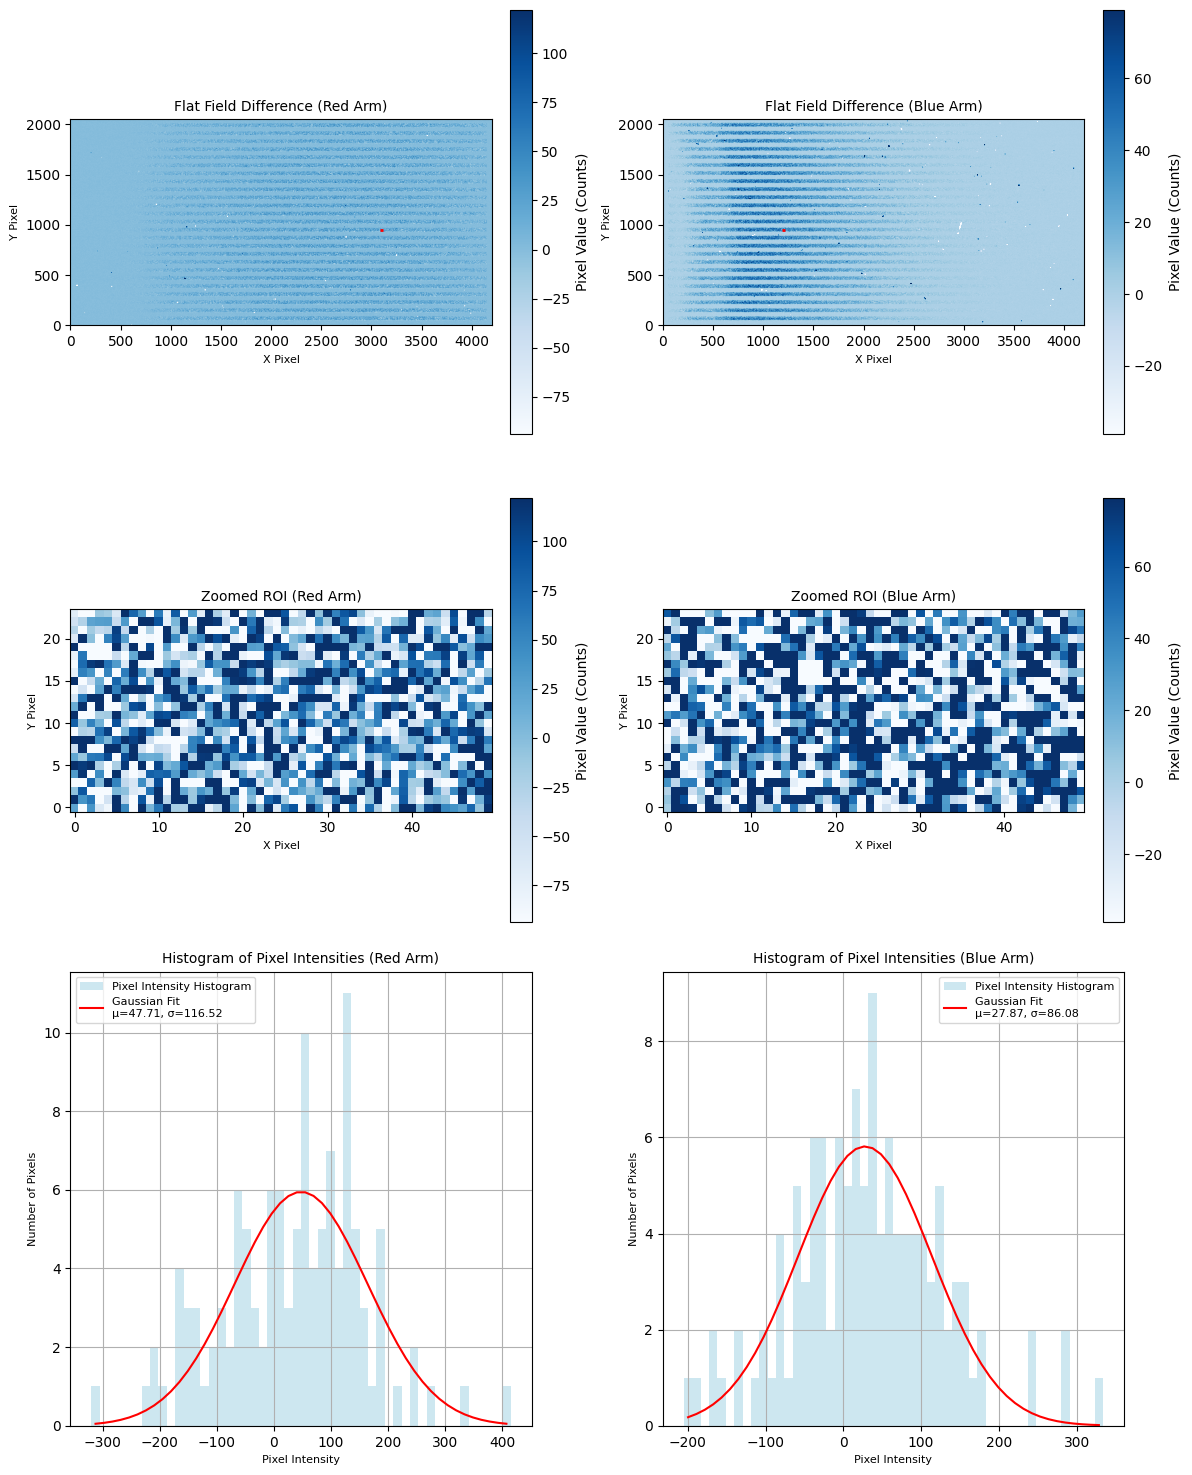

In [ ]:
# Function to process flat fields, subtract master bias, subtract one from the other, and analyze the ROI
def process_and_analyze_flat_fields(flat_file_1, flat_file_2, master_bias, region_width, region_height, offset_x, offset_y, arm_name, axes, col_index):
    with fits.open(flat_file_1) as hdul1, fits.open(flat_file_2) as hdul2:
        flat_data_1 = hdul1[0].data - master_bias  # Subtract master bias from the first flat
        flat_data_2 = hdul2[0].data - master_bias  # Subtract master bias from the second flat

        # Subtract one flat field from the other
        flat_data_diff = flat_data_1 - flat_data_2

        # Define a rectangular region in the frame with offsets
        center_x, center_y = flat_data_diff.shape[1] // 2, flat_data_diff.shape[0] // 2
        region = flat_data_diff[
            center_y + offset_y - region_height // 2 : center_y + offset_y + region_height // 2,
            center_x + offset_x - region_width // 2 : center_x + offset_x + region_width // 2
        ]

        # Calculate the standard deviation in the region
        stddev = np.std(region)

        # Calculate vmin and vmax using percentiles for better visualization
        vmin = np.percentile(flat_data_diff, 5)
        vmax = np.percentile(flat_data_diff, 95)

        # Plot the flat field difference with ROI
        ax_diff = axes[0, col_index]
        im_diff = ax_diff.imshow(flat_data_diff, cmap="Blues", origin="lower", vmin=vmin, vmax=vmax)
        ax_diff.set_title(f"Flat Field Difference ({arm_name} Arm)", fontsize=10)
        ax_diff.set_xlabel("X Pixel", fontsize=8)
        ax_diff.set_ylabel("Y Pixel", fontsize=8)
        plt.colorbar(im_diff, ax=ax_diff, fraction=0.046, pad=0.04, label="Pixel Value (Counts)")

        # Highlight the region of interest
        rect = plt.Rectangle(
            (center_x + offset_x - region_width // 2, center_y + offset_y - region_height // 2),
            region_width,
            region_height,
            edgecolor="red",
            facecolor="none",
            linewidth=2,
        )
        ax_diff.add_patch(rect)

        # Plot the zoomed-out ROI
        zoom_margin = 10  # Add margin around the ROI for better context
        zoomed_region = flat_data_diff[
            center_y + offset_y - region_height // 2 - zoom_margin : center_y + offset_y + region_height // 2 + zoom_margin,
            center_x + offset_x - region_width // 2 - zoom_margin : center_x + offset_x + region_width // 2 + zoom_margin
        ]
        ax_zoom = axes[1, col_index]
        im_zoom = ax_zoom.imshow(zoomed_region, cmap="Blues", origin="lower", vmin=vmin, vmax=vmax)
        ax_zoom.set_title(f"Zoomed ROI ({arm_name} Arm)", fontsize=10)
        ax_zoom.set_xlabel("X Pixel", fontsize=8)
        ax_zoom.set_ylabel("Y Pixel", fontsize=8)
        plt.colorbar(im_zoom, ax=ax_zoom, fraction=0.046, pad=0.04, label="Pixel Value (Counts)")

        # Plot the histogram of the ROI with Gaussian fit
        pixel_values = region.flatten()
        hist, bin_edges = np.histogram(pixel_values, bins=50)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        popt, _ = curve_fit(gaussian, bin_centers, hist, p0=[np.max(hist), np.mean(pixel_values), np.std(pixel_values)])

        ax_hist = axes[2, col_index]
        ax_hist.hist(pixel_values, bins=50, alpha=0.6, color="lightblue", label="Pixel Intensity Histogram")
        ax_hist.plot(bin_centers, gaussian(bin_centers, *popt), color="red", label=f"Gaussian Fit\nμ={popt[1]:.2f}, σ={popt[2]:.2f}")
        ax_hist.set_title(f"Histogram of Pixel Intensities ({arm_name} Arm)", fontsize=10)
        ax_hist.set_xlabel("Pixel Intensity", fontsize=8)
        ax_hist.set_ylabel("Number of Pixels", fontsize=8)
        ax_hist.legend(fontsize=8)
        ax_hist.grid(True)

        # Print the standard deviation and Gaussian fit parameters
        print(f"Standard Deviation in Region ({arm_name} Arm): {stddev:.2f} ADU")
        print(f"Gaussian Fit Parameters for {arm_name} Arm: μ={popt[1]:.2f}, σ={popt[2]:.2f}")

# Example usage
# Paths to the flat fields
flat_file_red_1 = "/Users/Ishfahanirusyda/Documents/Obstech/BiasFlats/FLATS/Red/OBK-709344-WiFeS-Red--UT20250315T000118-1.fits"
flat_file_red_2 = "/Users/Ishfahanirusyda/Documents/Obstech/BiasFlats/FLATS/Red/OBK-709344-WiFeS-Red--UT20250315T000426-4.fits"
flat_file_blue_1 = "/Users/Ishfahanirusyda/Documents/Obstech/BiasFlats/FLATS/Blue/OBK-709440-WiFeS-Blue-UT20250315T000744-7.fits"
flat_file_blue_2 = "/Users/Ishfahanirusyda/Documents/Obstech/BiasFlats/FLATS/Blue/OBK-709440-WiFeS-Blue-UT20250315T000605-6.fits"

# Paths to the master biases
master_bias_red_path = "/Users/Ishfahanirusyda/Documents/Obstech/BiasFlats/BIAS/Red/master_bias_Red.fits"
master_bias_blue_path = "/Users/Ishfahanirusyda/Documents/Obstech/BiasFlats/BIAS/Blue/master_bias_Blue.fits"

# Load the master biases
with fits.open(master_bias_red_path) as hdul:
    master_bias_red = hdul[0].data

with fits.open(master_bias_blue_path) as hdul:
    master_bias_blue = hdul[0].data

# Define ROI parameters
region_width = 30  # Width of the rectangular region
region_height = 5  # Height of the rectangular region
red_offset = (1000, -82)  # Offset for the red arm (x_offset, y_offset)
blue_offset = (-900, -80)  # Offset for the blue arm (x_offset, y_offset)

# Create a single figure with 6 subplots (3 rows, 2 columns)
fig, axes = plt.subplots(3, 2, figsize=(12, 15))  # 3 rows, 2 columns for side-by-side plots

# Process and analyze the red arm flat fields
process_and_analyze_flat_fields(flat_file_red_1, flat_file_red_2, master_bias_red, region_width, region_height, red_offset[0], red_offset[1], "Red", axes, col_index=0)

# Process and analyze the blue arm flat fields
process_and_analyze_flat_fields(flat_file_blue_1, flat_file_blue_2, master_bias_blue, region_width, region_height, blue_offset[0], blue_offset[1], "Blue", axes, col_index=1)

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

## Question 6

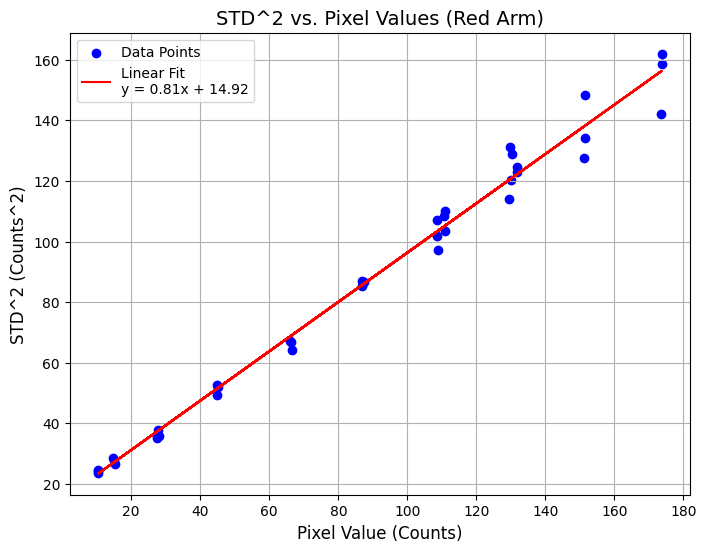

Red Arm Linear Fit:
Slope: 0.81
Intercept: 14.92
R-squared: 0.99


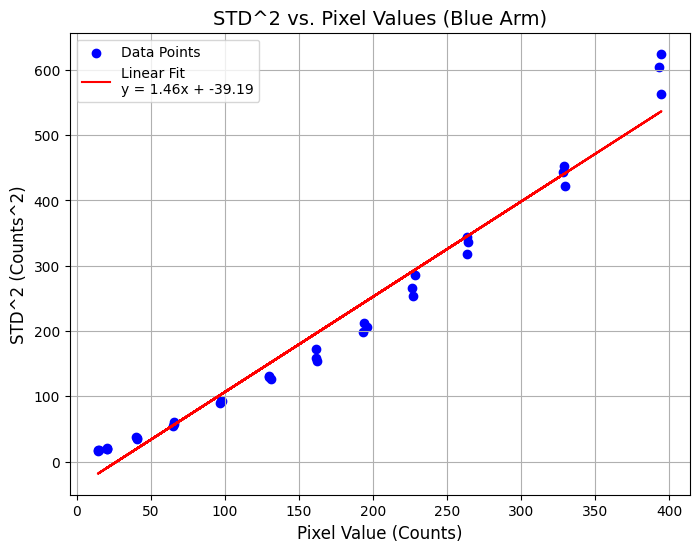

Blue Arm Linear Fit:
Slope: 1.46
Intercept: -39.19
R-squared: 0.97


In [ ]:
# Function to process flat fields and calculate pixel value and std for the ROI
def process_flat_fields(flat_folder, master_bias, region_size, offset_x, offset_y, arm_name):
    flat_files = [os.path.join(flat_folder, f) for f in os.listdir(flat_folder) if f.lower().endswith(".fits")]
    pixel_values = []
    std_values = []

    for flat_file in flat_files:
        with fits.open(flat_file) as hdul:
            flat_data = hdul[0].data - master_bias  # Subtract master bias

            # Define a square region in the frame with offsets
            center_x, center_y = flat_data.shape[1] // 2, flat_data.shape[0] // 2
            region = flat_data[
                center_y + offset_y - region_size // 2 : center_y + offset_y + region_size // 2,
                center_x + offset_x - region_size // 2 : center_x + offset_x + region_size // 2
            ]

            # Calculate the mean pixel value and standard deviation in the region
            mean_pixel_value = np.mean(region)
            stddev = np.std(region)

            # Append the results
            pixel_values.append(mean_pixel_value)
            std_values.append(stddev)

    # Convert to numpy arrays for easier manipulation
    pixel_values = np.array(pixel_values)
    std_values = np.array(std_values)

    # Calculate std^2
    std_squared = std_values ** 2

    # Perform a linear fit
    slope, intercept, r_value, p_value, std_err = linregress(pixel_values, std_squared)

    # Plot std^2 vs. pixel values
    plt.figure(figsize=(8, 6))
    plt.scatter(pixel_values, std_squared, color="blue", label="Data Points")
    plt.plot(pixel_values, slope * pixel_values + intercept, color="red", label=f"Linear Fit\ny = {slope:.2f}x + {intercept:.2f}")
    plt.title(f"STD^2 vs. Pixel Values ({arm_name} Arm)", fontsize=14)
    plt.xlabel("Pixel Value (Counts)", fontsize=12)
    plt.ylabel("STD^2 (Counts^2)", fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True)
    plt.show()

    # Print the fit parameters
    print(f"{arm_name} Arm Linear Fit:")
    print(f"Slope: {slope:.2f}")
    print(f"Intercept: {intercept:.2f}")
    print(f"R-squared: {r_value**2:.2f}")

# Paths to the flat folders and master biases
flat_folder_red = "/Users/Ishfahanirusyda/Documents/Obstech/BiasFlats/FLATS/Red"
flat_folder_blue = "/Users/Ishfahanirusyda/Documents/Obstech/BiasFlats/FLATS/Blue"
master_bias_red_path = "/Users/Ishfahanirusyda/Documents/Obstech/BiasFlats/BIAS/Red/master_bias_Red.fits"
master_bias_blue_path = "/Users/Ishfahanirusyda/Documents/Obstech/BiasFlats/BIAS/Blue/master_bias_Blue.fits"

# Load the master biases
with fits.open(master_bias_red_path) as hdul:
    master_bias_red = hdul[0].data

with fits.open(master_bias_blue_path) as hdul:
    master_bias_blue = hdul[0].data

# Define ROI parameters
region_size = 30  # Size of the square region (e.g., 30x30 pixels)
red_offset = (1000, -120)  # Offset for the red arm (x_offset, y_offset)
blue_offset = (1000, -80)   # Offset for the blue arm (x_offset, y_offset)

# Process and plot for the red arm
process_flat_fields(flat_folder_red, master_bias_red, region_size, red_offset[0], red_offset[1], "Red")

# Process and plot for the blue arm
process_flat_fields(flat_folder_blue, master_bias_blue, region_size, blue_offset[0], blue_offset[1], "Blue")

Red Arm Linear Fit:
Slope: 16.29
Intercept: -40867.73
R-squared: 0.94
Blue Arm Linear Fit:
Slope: 0.94
Intercept: -717.09
R-squared: 0.96


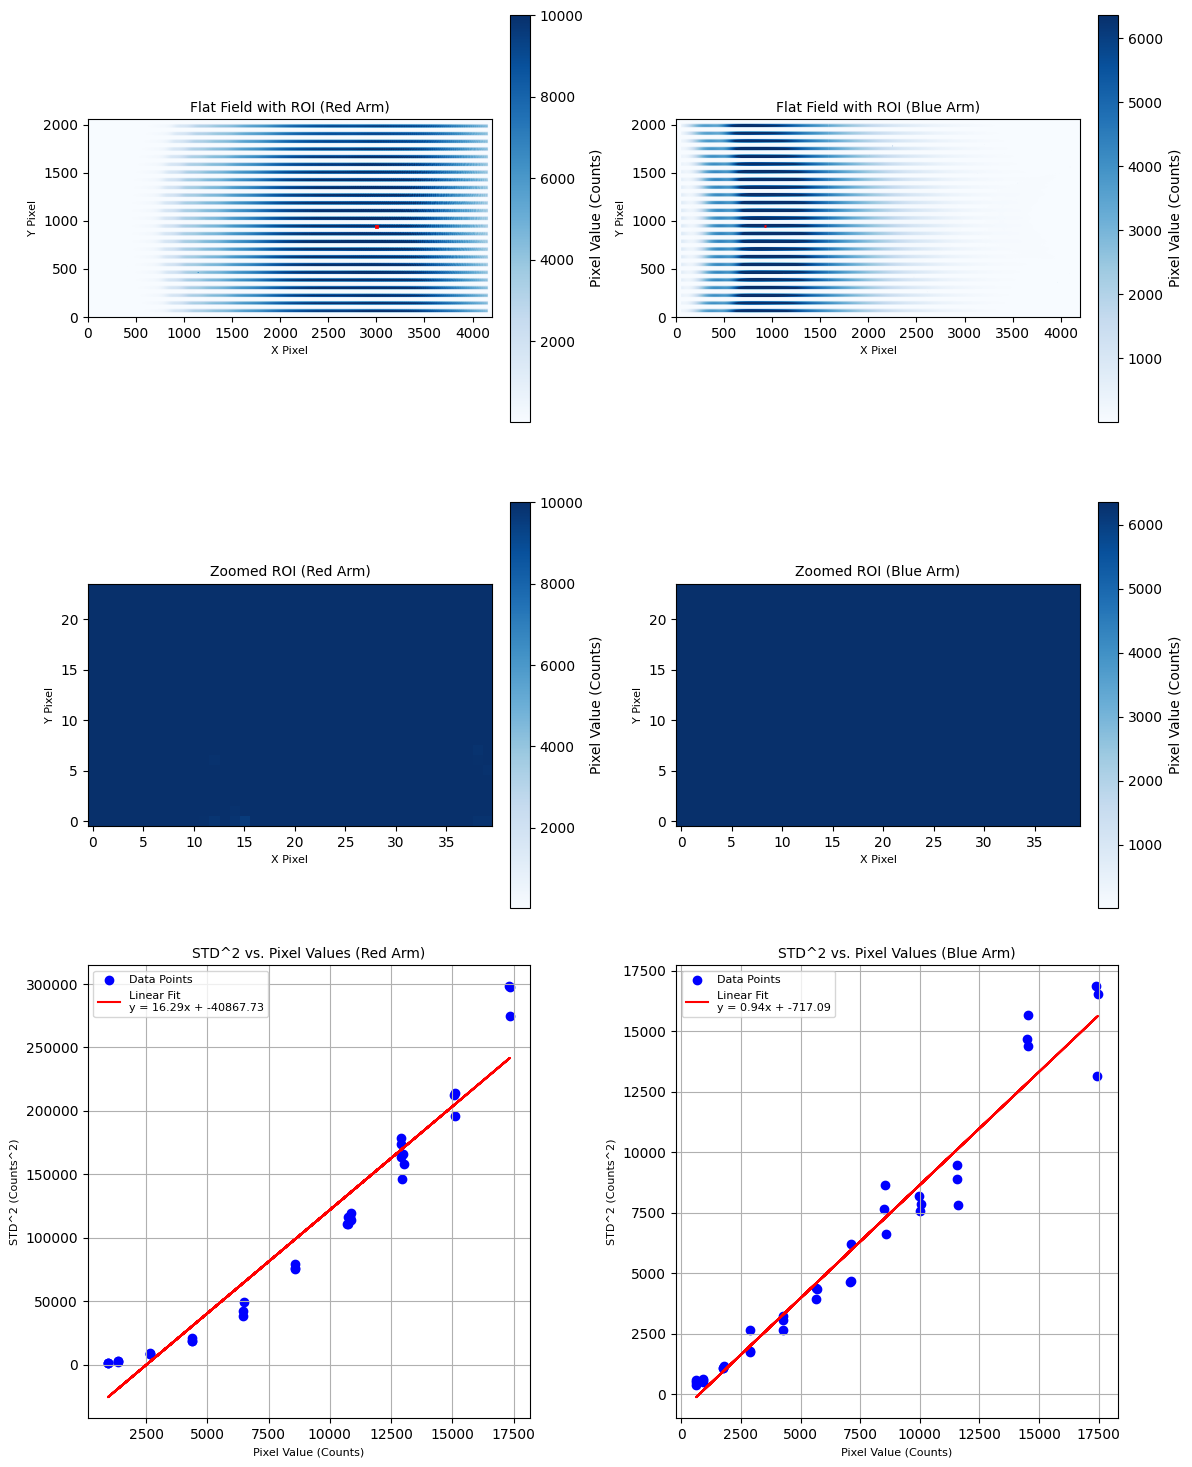

In [ ]:
# Function to process flat fields and calculate pixel value and std for the ROI
def process_flat_fields(flat_folder, master_bias, region_width, region_height, offset_x, offset_y, arm_name, axes, col_index):
    flat_files = [os.path.join(flat_folder, f) for f in os.listdir(flat_folder) if f.lower().endswith(".fits")]
    pixel_values = []
    std_values = []

    for flat_file in flat_files:
        with fits.open(flat_file) as hdul:
            flat_data = hdul[0].data - master_bias  # Subtract master bias

            # Define a rectangular region in the frame with offsets
            center_x, center_y = flat_data.shape[1] // 2, flat_data.shape[0] // 2
            region = flat_data[
                center_y + offset_y - region_height // 2 : center_y + offset_y + region_height // 2,
                center_x + offset_x - region_width // 2 : center_x + offset_x + region_width // 2
            ]

            # Calculate the mean pixel value and standard deviation in the region
            mean_pixel_value = np.mean(region)
            stddev = np.std(region)

            # Append the results
            pixel_values.append(mean_pixel_value)
            std_values.append(stddev)

    # Convert to numpy arrays for easier manipulation
    pixel_values = np.array(pixel_values)
    std_values = np.array(std_values)

    # Calculate std^2
    std_squared = std_values ** 2

    # Perform a linear fit
    slope, intercept, r_value, p_value, std_err = linregress(pixel_values, std_squared)

    # Plot the flat field with ROI
    example_flat_file = flat_files[0]
    with fits.open(example_flat_file) as hdul:
        example_data = hdul[0].data - master_bias

    vmin = np.percentile(example_data, 5)
    vmax = np.percentile(example_data, 95)

    ax_flat = axes[0, col_index]
    im_flat = ax_flat.imshow(example_data, cmap="Blues", origin="lower", vmin=vmin, vmax=vmax)
    ax_flat.set_title(f"Flat Field with ROI ({arm_name} Arm)", fontsize=10)
    ax_flat.set_xlabel("X Pixel", fontsize=8)
    ax_flat.set_ylabel("Y Pixel", fontsize=8)
    plt.colorbar(im_flat, ax=ax_flat, fraction=0.046, pad=0.04, label="Pixel Value (Counts)")

    # Highlight the region of interest
    rect = plt.Rectangle(
        (center_x + offset_x - region_width // 2, center_y + offset_y - region_height // 2),
        region_width,
        region_height,
        edgecolor="red",
        facecolor="none",
        linewidth=2,
    )
    ax_flat.add_patch(rect)

    # Plot the zoomed ROI
    zoom_margin = 10  # Add margin around the ROI for better context
    zoomed_region = example_data[
        center_y + offset_y - region_height // 2 - zoom_margin : center_y + offset_y + region_height // 2 + zoom_margin,
        center_x + offset_x - region_width // 2 - zoom_margin : center_x + offset_x + region_width // 2 + zoom_margin
    ]
    ax_zoom = axes[1, col_index]
    im_zoom = ax_zoom.imshow(zoomed_region, cmap="Blues", origin="lower", vmin=vmin, vmax=vmax)
    ax_zoom.set_title(f"Zoomed ROI ({arm_name} Arm)", fontsize=10)
    ax_zoom.set_xlabel("X Pixel", fontsize=8)
    ax_zoom.set_ylabel("Y Pixel", fontsize=8)
    plt.colorbar(im_zoom, ax=ax_zoom, fraction=0.046, pad=0.04, label="Pixel Value (Counts)")

    # Plot std^2 vs. pixel values
    ax_std = axes[2, col_index]
    ax_std.scatter(pixel_values, std_squared, color="blue", label="Data Points")
    ax_std.plot(pixel_values, slope * pixel_values + intercept, color="red", label=f"Linear Fit\ny = {slope:.2f}x + {intercept:.2f}")
    ax_std.set_title(f"STD^2 vs. Pixel Values ({arm_name} Arm)", fontsize=10)
    ax_std.set_xlabel("Pixel Value (Counts)", fontsize=8)
    ax_std.set_ylabel("STD^2 (Counts^2)", fontsize=8)
    ax_std.legend(fontsize=8)
    ax_std.grid(True)

    # Print the fit parameters
    print(f"{arm_name} Arm Linear Fit:")
    print(f"Slope: {slope:.2f}")
    print(f"Intercept: {intercept:.2f}")
    print(f"R-squared: {r_value**2:.2f}")

# Paths to the flat folders and master biases
flat_folder_red = "/Users/Ishfahanirusyda/Documents/Obstech/BiasFlats/FLATS/Red"
flat_folder_blue = "/Users/Ishfahanirusyda/Documents/Obstech/BiasFlats/FLATS/Blue"
master_bias_red_path = "/Users/Ishfahanirusyda/Documents/Obstech/BiasFlats/BIAS/Red/master_bias_Red.fits"
master_bias_blue_path = "/Users/Ishfahanirusyda/Documents/Obstech/BiasFlats/BIAS/Blue/master_bias_Blue.fits"

# Load the master biases
with fits.open(master_bias_red_path) as hdul:
    master_bias_red = hdul[0].data

with fits.open(master_bias_blue_path) as hdul:
    master_bias_blue = hdul[0].data

# Define ROI parameters
region_width = 20  # Width of the rectangular region
region_height = 5  # Height of the rectangular region
red_offset = (900, -88)  # Offset for the red arm (x_offset, y_offset)
blue_offset = (-1180, -80)  # Offset for the blue arm (x_offset, y_offset)

# Create a single figure with 6 subplots (3 rows, 2 columns)
fig, axes = plt.subplots(3, 2, figsize=(12, 15))  # 3 rows, 2 columns for side-by-side plots

# Process and plot for the red arm
process_flat_fields(flat_folder_red, master_bias_red, region_width, region_height, red_offset[0], red_offset[1], "Red", axes, col_index=0)

# Process and plot for the blue arm
process_flat_fields(flat_folder_blue, master_bias_blue, region_width, region_height, blue_offset[0], blue_offset[1], "Blue", axes, col_index=1)

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

Red Arm Linear Fit:
Slope: 0.75
Intercept: 338.97
R-squared: 0.85
Blue Arm Linear Fit:
Slope: 0.62
Intercept: 190.89
R-squared: 0.93


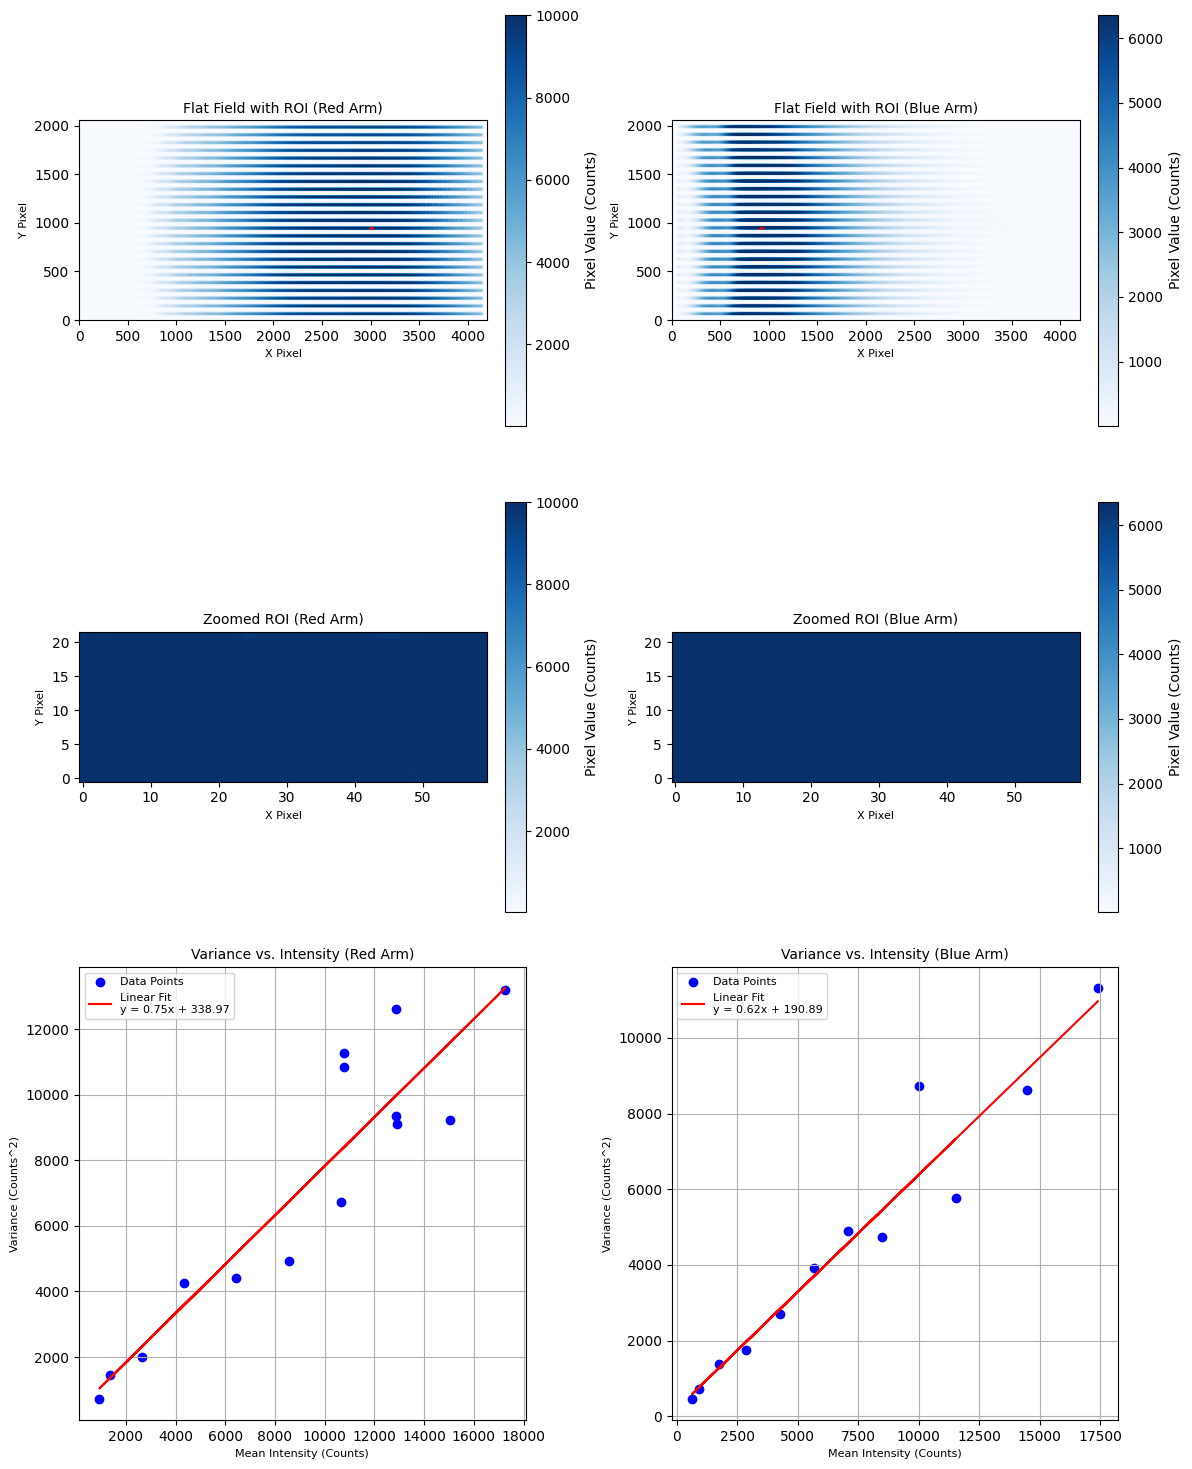

In [ ]:
# Function to find pairs of flat fields with the same exposure time
def find_flat_field_pairs(flat_folder):
    exptime_dict = {}
    flat_files = [os.path.join(flat_folder, f) for f in os.listdir(flat_folder) if f.lower().endswith(".fits")]

    # Group files by exposure time
    for flat_file in flat_files:
        with fits.open(flat_file) as hdul:
            exptime = hdul[0].header.get("EXPTIME", None)
            if exptime is not None:
                if exptime not in exptime_dict:
                    exptime_dict[exptime] = []
                exptime_dict[exptime].append(flat_file)

    # Find pairs of files
    pairs = []
    for exptime, files in exptime_dict.items():
        if len(files) >= 2:
            for i in range(0, len(files) - 1, 2):  # Take pairs
                pairs.append((files[i], files[i + 1]))
    return pairs

# Function to process flat field pairs and calculate intensity and variance
def process_flat_field_pairs(flat_pairs, master_bias, region_width, region_height, offset_x, offset_y, arm_name, axes, col_index):
    intensities = []
    variances = []

    for flat_file_1, flat_file_2 in flat_pairs:
        with fits.open(flat_file_1) as hdul1, fits.open(flat_file_2) as hdul2:
            flat_data_1 = hdul1[0].data - master_bias
            flat_data_2 = hdul2[0].data - master_bias

            # Subtract one flat field from the other
            flat_data_diff = flat_data_1 - flat_data_2

            # Define a rectangular region in the frame with offsets
            center_x, center_y = flat_data_diff.shape[1] // 2, flat_data_diff.shape[0] // 2
            region_diff = flat_data_diff[
                center_y + offset_y - region_height // 2 : center_y + offset_y + region_height // 2,
                center_x + offset_x - region_width // 2 : center_x + offset_x + region_width // 2
            ]

            # Calculate the average pixel value from both files in the region
            region_avg = (flat_data_1 + flat_data_2) / 2
            region_avg = region_avg[
                center_y + offset_y - region_height // 2 : center_y + offset_y + region_height // 2,
                center_x + offset_x - region_width // 2 : center_x + offset_x + region_width // 2
            ]

            # Calculate mean intensity and variance
            mean_intensity = np.mean(region_avg)
            variance = np.var(region_diff) / 2  # sigma_diff = 2 * sigma_A^2 -> sigma_A^2 = variance / 2

            intensities.append(mean_intensity)
            variances.append(variance)

    # Convert to numpy arrays for easier manipulation
    intensities = np.array(intensities)
    variances = np.array(variances)

    # Perform a linear fit
    slope, intercept, r_value, p_value, std_err = linregress(intensities, variances)

    # Plot the flat field with ROI
    example_flat_file = flat_pairs[0][0]
    with fits.open(example_flat_file) as hdul:
        example_data = hdul[0].data - master_bias

    vmin = np.percentile(example_data, 5)
    vmax = np.percentile(example_data, 95)

    ax_flat = axes[0, col_index]
    im_flat = ax_flat.imshow(example_data, cmap="Blues", origin="lower", vmin=vmin, vmax=vmax)
    ax_flat.set_title(f"Flat Field with ROI ({arm_name} Arm)", fontsize=10)
    ax_flat.set_xlabel("X Pixel", fontsize=8)
    ax_flat.set_ylabel("Y Pixel", fontsize=8)
    plt.colorbar(im_flat, ax=ax_flat, fraction=0.046, pad=0.04, label="Pixel Value (Counts)")

    # Highlight the region of interest
    rect = plt.Rectangle(
        (center_x + offset_x - region_width // 2, center_y + offset_y - region_height // 2),
        region_width,
        region_height,
        edgecolor="red",
        facecolor="none",
        linewidth=2,
    )
    ax_flat.add_patch(rect)

    # Plot the zoomed ROI
    zoom_margin = 10  # Add margin around the ROI for better context
    zoomed_region = example_data[
        center_y + offset_y - region_height // 2 - zoom_margin : center_y + offset_y + region_height // 2 + zoom_margin,
        center_x + offset_x - region_width // 2 - zoom_margin : center_x + offset_x + region_width // 2 + zoom_margin
    ]
    ax_zoom = axes[1, col_index]
    im_zoom = ax_zoom.imshow(zoomed_region, cmap="Blues", origin="lower", vmin=vmin, vmax=vmax)
    ax_zoom.set_title(f"Zoomed ROI ({arm_name} Arm)", fontsize=10)
    ax_zoom.set_xlabel("X Pixel", fontsize=8)
    ax_zoom.set_ylabel("Y Pixel", fontsize=8)
    plt.colorbar(im_zoom, ax=ax_zoom, fraction=0.046, pad=0.04, label="Pixel Value (Counts)")

    # Plot intensity vs. variance
    ax_std = axes[2, col_index]
    ax_std.scatter(intensities, variances, color="blue", label="Data Points")
    ax_std.plot(intensities, slope * intensities + intercept, color="red", label=f"Linear Fit\ny = {slope:.2f}x + {intercept:.2f}")
    ax_std.set_title(f"Variance vs. Intensity ({arm_name} Arm)", fontsize=10)
    ax_std.set_xlabel("Mean Intensity (Counts)", fontsize=8)
    ax_std.set_ylabel("Variance (Counts^2)", fontsize=8)
    ax_std.legend(fontsize=8)
    ax_std.grid(True)

    # Print the fit parameters
    print(f"{arm_name} Arm Linear Fit:")
    print(f"Slope: {slope:.2f}")
    print(f"Intercept: {intercept:.2f}")
    print(f"R-squared: {r_value**2:.2f}")

# Paths to the flat folders and master biases
flat_folder_red = "/Users/Ishfahanirusyda/Documents/Obstech/BiasFlats/FLATS/Red"
flat_folder_blue = "/Users/Ishfahanirusyda/Documents/Obstech/BiasFlats/FLATS/Blue"
master_bias_red_path = "/Users/Ishfahanirusyda/Documents/Obstech/BiasFlats/BIAS/Red/master_bias_Red.fits"
master_bias_blue_path = "/Users/Ishfahanirusyda/Documents/Obstech/BiasFlats/BIAS/Blue/master_bias_Blue.fits"

# Load the master biases
with fits.open(master_bias_red_path) as hdul:
    master_bias_red = hdul[0].data

with fits.open(master_bias_blue_path) as hdul:
    master_bias_blue = hdul[0].data

# Define ROI parameters
region_width = 40  # Width of the rectangular region
region_height = 2  # Height of the rectangular region
red_offset = (900, -83)  # Offset for the red arm (x_offset, y_offset)
blue_offset = (-1180, -78)  # Offset for the blue arm (x_offset, y_offset)

# Find pairs of flat fields
flat_pairs_red = find_flat_field_pairs(flat_folder_red)
flat_pairs_blue = find_flat_field_pairs(flat_folder_blue)

# Create a single figure with 6 subplots (3 rows, 2 columns)
fig, axes = plt.subplots(3, 2, figsize=(12, 15))  # 3 rows, 2 columns for side-by-side plots

# Process and plot for the red arm
process_flat_field_pairs(flat_pairs_red, master_bias_red, region_width, region_height, red_offset[0], red_offset[1], "Red", axes, col_index=0)

# Process and plot for the blue arm
process_flat_field_pairs(flat_pairs_blue, master_bias_blue, region_width, region_height, blue_offset[0], blue_offset[1], "Blue", axes, col_index=1)

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

In [ ]:
# Path to the Darks folder
darks_folder = "/Users/Ishfahanirusyda/Documents/Obstech/Darks"

# Create subfolders for "Red" and "Blue" within "Darks"
darks_red_folder = os.path.join(darks_folder, "Red")
darks_blue_folder = os.path.join(darks_folder, "Blue")

# Create the directories if they don't exist
os.makedirs(darks_red_folder, exist_ok=True)
os.makedirs(darks_blue_folder, exist_ok=True)

# Iterate through the files in the "Darks" folder
for filename in os.listdir(darks_folder):
    if filename.lower().endswith(".fits"):
        file_path = os.path.join(darks_folder, filename)
        try:
            with fits.open(file_path) as hdul:
                header = hdul[0].header
                arm = header.get("ARM", "").strip().capitalize()

                if arm == "Red":
                    shutil.move(file_path, os.path.join(darks_red_folder, filename))
                    print(f"Moved {filename} to Darks/Red folder.")
                elif arm == "Blue":
                    shutil.move(file_path, os.path.join(darks_blue_folder, filename))
                    print(f"Moved {filename} to Darks/Blue folder.")
                else:
                    print(f"{filename}: ARM='{arm}' not recognized, skipping.")
        except Exception as e:
            print(f"Error processing {filename}: {e}")

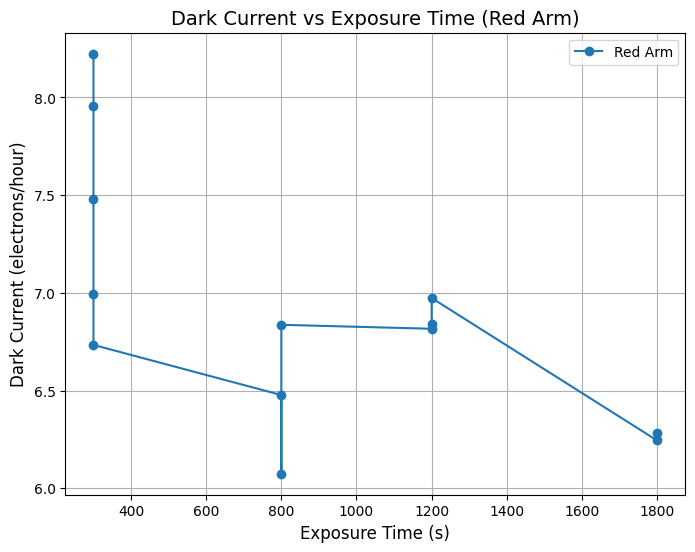

Red Arm:
Exposure Time: 300.00 s, Dark Current: 8.22 electrons/hour
Exposure Time: 300.00 s, Dark Current: 7.95 electrons/hour
Exposure Time: 300.00 s, Dark Current: 7.48 electrons/hour
Exposure Time: 300.00 s, Dark Current: 6.99 electrons/hour
Exposure Time: 300.00 s, Dark Current: 6.73 electrons/hour
Exposure Time: 800.00 s, Dark Current: 6.48 electrons/hour
Exposure Time: 800.00 s, Dark Current: 6.07 electrons/hour
Exposure Time: 800.00 s, Dark Current: 6.84 electrons/hour
Exposure Time: 1200.00 s, Dark Current: 6.82 electrons/hour
Exposure Time: 1200.00 s, Dark Current: 6.84 electrons/hour
Exposure Time: 1200.00 s, Dark Current: 6.97 electrons/hour
Exposure Time: 1800.00 s, Dark Current: 6.24 electrons/hour
Exposure Time: 1800.00 s, Dark Current: 6.28 electrons/hour


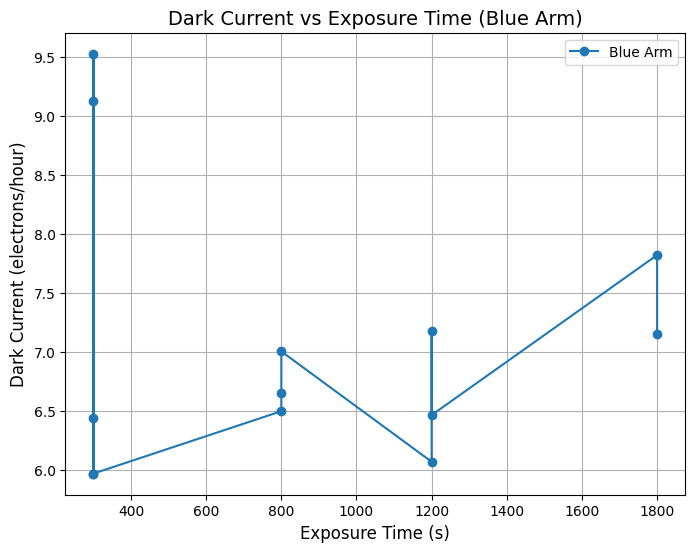

Blue Arm:
Exposure Time: 300.00 s, Dark Current: 5.97 electrons/hour
Exposure Time: 300.00 s, Dark Current: 9.52 electrons/hour
Exposure Time: 300.00 s, Dark Current: 9.13 electrons/hour
Exposure Time: 300.00 s, Dark Current: 6.44 electrons/hour
Exposure Time: 300.00 s, Dark Current: 5.97 electrons/hour
Exposure Time: 800.00 s, Dark Current: 6.50 electrons/hour
Exposure Time: 800.00 s, Dark Current: 6.65 electrons/hour
Exposure Time: 800.00 s, Dark Current: 7.00 electrons/hour
Exposure Time: 1200.00 s, Dark Current: 6.07 electrons/hour
Exposure Time: 1200.00 s, Dark Current: 7.18 electrons/hour
Exposure Time: 1200.00 s, Dark Current: 6.46 electrons/hour
Exposure Time: 1800.00 s, Dark Current: 7.82 electrons/hour
Exposure Time: 1800.00 s, Dark Current: 7.15 electrons/hour


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

# Function to process dark frames and calculate dark current
def process_dark_frames(dark_folder, arm_name):
    dark_files = [os.path.join(dark_folder, f) for f in os.listdir(dark_folder) if f.lower().endswith(".fits")]
    exposure_times = []
    dark_currents = []

    for dark_file in dark_files:
        with fits.open(dark_file) as hdul:
            header = hdul[0].header
            data = hdul[0].data

            # Extract exposure time from the header
            exptime = header.get("EXPTIME", None)
            if exptime is None:
                print(f"Exposure time not found in {dark_file}, skipping.")
                continue

            # Calculate the mean pixel value in the dark frame
            mean_pixel_value = np.mean(data)

            # Assuming gain = 1, calculate dark current in electrons/hour
            dark_current = (mean_pixel_value / exptime) * 3600  # Convert to electrons/hour

            # Append results
            exposure_times.append(exptime)
            dark_currents.append(dark_current)

    # Sort data by exposure time
    exposure_times = np.array(exposure_times)
    dark_currents = np.array(dark_currents)
    sorted_indices = np.argsort(exposure_times)
    exposure_times = exposure_times[sorted_indices]
    dark_currents = dark_currents[sorted_indices]

    # Plot dark current vs exposure time
    plt.figure(figsize=(8, 6))
    plt.plot(exposure_times, dark_currents, marker="o", linestyle="-", label=f"{arm_name} Arm")
    plt.title(f"Dark Current vs Exposure Time ({arm_name} Arm)", fontsize=14)
    plt.xlabel("Exposure Time (s)", fontsize=12)
    plt.ylabel("Dark Current (electrons/hour)", fontsize=12)
    plt.grid(True)
    plt.legend(fontsize=10)
    plt.show()

    # Print results
    print(f"{arm_name} Arm:")
    for exptime, dark_current in zip(exposure_times, dark_currents):
        print(f"Exposure Time: {exptime:.2f} s, Dark Current: {dark_current:.2f} electrons/hour")

# Paths to the dark folders
darks_red_folder = "/Users/Ishfahanirusyda/Documents/Obstech/Darks/Red"
darks_blue_folder = "/Users/Ishfahanirusyda/Documents/Obstech/Darks/Blue"

# Process and plot for the red arm
process_dark_frames(darks_red_folder, "Red")

# Process and plot for the blue arm
process_dark_frames(darks_blue_folder, "Blue")

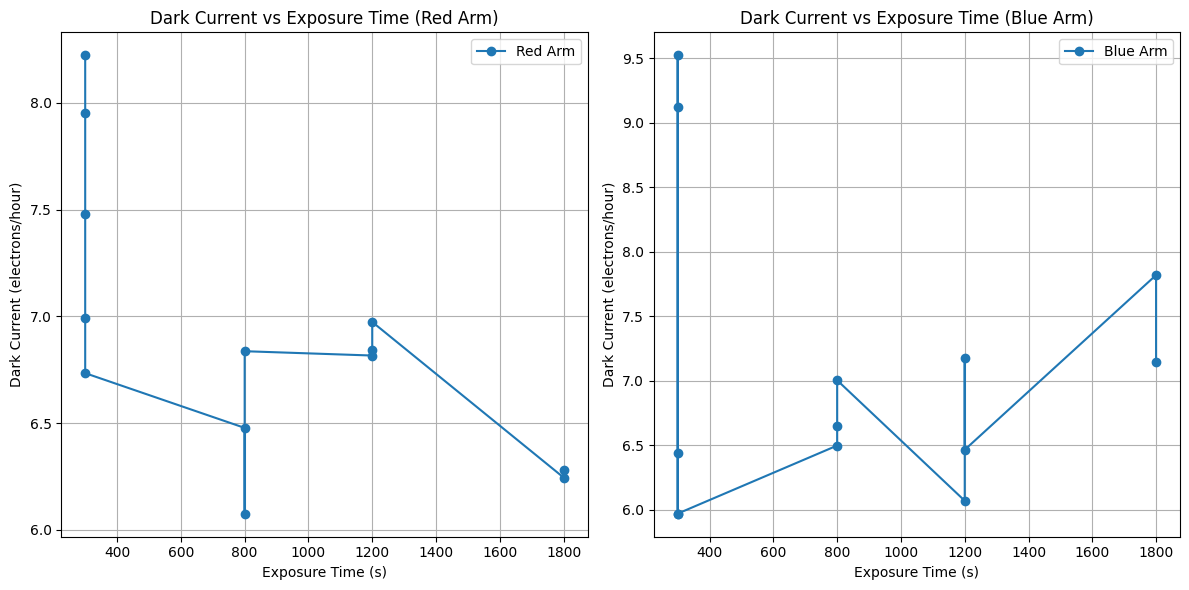

In [ ]:
# Function to process dark frames and calculate dark current
def process_dark_frames(dark_folder, arm_name):
    dark_files = [os.path.join(dark_folder, f) for f in os.listdir(dark_folder) if f.lower().endswith(".fits")]
    exposure_times = []
    dark_currents = []

    for dark_file in dark_files:
        with fits.open(dark_file) as hdul:
            header = hdul[0].header
            data = hdul[0].data

            # Extract exposure time from the header
            exptime = header.get("EXPTIME", None)
            if exptime is None:
                print(f"Exposure time not found in {dark_file}, skipping.")
                continue

            # Calculate the mean pixel value in the dark frame
            mean_pixel_value = np.mean(data)

            # Assuming gain = 1, calculate dark current in electrons/hour
            dark_current = (mean_pixel_value / exptime) * 3600  # Convert to electrons/hour

            # Append results
            exposure_times.append(exptime)
            dark_currents.append(dark_current)

    # Sort data by exposure time
    exposure_times = np.array(exposure_times)
    dark_currents = np.array(dark_currents)
    sorted_indices = np.argsort(exposure_times)
    exposure_times = exposure_times[sorted_indices]
    dark_currents = dark_currents[sorted_indices]

    return exposure_times, dark_currents

# Paths to the dark folders
darks_red_folder = "/Users/Ishfahanirusyda/Documents/Obstech/Darks/Red"
darks_blue_folder = "/Users/Ishfahanirusyda/Documents/Obstech/Darks/Blue"

# Process data for both arms
exposure_times_red, dark_currents_red = process_dark_frames(darks_red_folder, "Red")
exposure_times_blue, dark_currents_blue = process_dark_frames(darks_blue_folder, "Blue")

# Create a single figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot for the red arm
axes[0].plot(exposure_times_red, dark_currents_red, marker="o", linestyle="-", label="Red Arm")
axes[0].set_title("Dark Current vs Exposure Time (Red Arm)", fontsize=12)
axes[0].set_xlabel("Exposure Time (s)", fontsize=10)
axes[0].set_ylabel("Dark Current (electrons/hour)", fontsize=10)
axes[0].grid(True)
axes[0].legend(fontsize=10)

# Plot for the blue arm
axes[1].plot(exposure_times_blue, dark_currents_blue, marker="o", linestyle="-", label="Blue Arm")
axes[1].set_title("Dark Current vs Exposure Time (Blue Arm)", fontsize=12)
axes[1].set_xlabel("Exposure Time (s)", fontsize=10)
axes[1].set_ylabel("Dark Current (electrons/hour)", fontsize=10)
axes[1].grid(True)
axes[1].legend(fontsize=10)

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

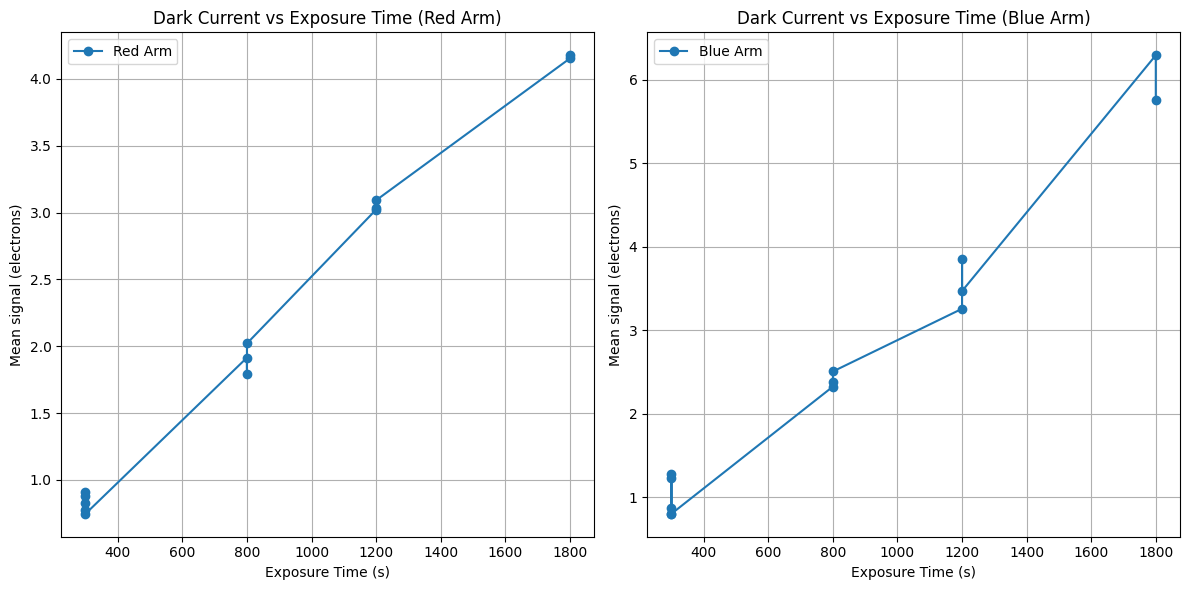

In [ ]:
# Function to process dark frames and calculate dark current
def process_dark_frames(dark_folder, arm_name, gain):
    dark_files = [os.path.join(dark_folder, f) for f in os.listdir(dark_folder) if f.lower().endswith(".fits")]
    exposure_times = []
    dark_currents = []

    for dark_file in dark_files:
        with fits.open(dark_file) as hdul:
            header = hdul[0].header
            data = hdul[0].data

            # Extract exposure time from the header
            exptime = header.get("EXPTIME", None)
            if exptime is None:
                print(f"Exposure time not found in {dark_file}, skipping.")
                continue

            # Calculate the mean pixel value in the dark frame
            mean_pixel_value = np.mean(data)

            # Calculate dark current in electrons/hour using the specified gain
            dark_current = (mean_pixel_value )* gain  # Convert to electrons/hour

            # Append results
            exposure_times.append(exptime)
            dark_currents.append(dark_current)

    # Sort data by exposure time
    exposure_times = np.array(exposure_times)
    dark_currents = np.array(dark_currents)
    sorted_indices = np.argsort(exposure_times)
    exposure_times = exposure_times[sorted_indices]
    dark_currents = dark_currents[sorted_indices]

    return exposure_times, dark_currents

# Paths to the dark folders
darks_red_folder = "/Users/Ishfahanirusyda/Documents/Obstech/Darks/Red"
darks_blue_folder = "/Users/Ishfahanirusyda/Documents/Obstech/Darks/Blue"

# Process data for both arms with respective gains
gain_red = 1.33
gain_blue = 1.61
exposure_times_red, dark_currents_red = process_dark_frames(darks_red_folder, "Red", gain_red)
exposure_times_blue, dark_currents_blue = process_dark_frames(darks_blue_folder, "Blue", gain_blue)

# Create a single figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot for the red arm
axes[0].plot(exposure_times_red, dark_currents_red, marker="o", linestyle="-", label="Red Arm")
axes[0].set_title("Dark Current vs Exposure Time (Red Arm)", fontsize=12)
axes[0].set_xlabel("Exposure Time (s)", fontsize=10)
axes[0].set_ylabel("Mean signal (electrons)", fontsize=10)
axes[0].grid(True)
axes[0].legend(fontsize=10)

# Plot for the blue arm
axes[1].plot(exposure_times_blue, dark_currents_blue, marker="o", linestyle="-", label="Blue Arm")
axes[1].set_title("Dark Current vs Exposure Time (Blue Arm)", fontsize=12)
axes[1].set_xlabel("Exposure Time (s)", fontsize=10)
axes[1].set_ylabel("Mean signal (electrons)", fontsize=10)
axes[1].grid(True)
axes[1].legend(fontsize=10)

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

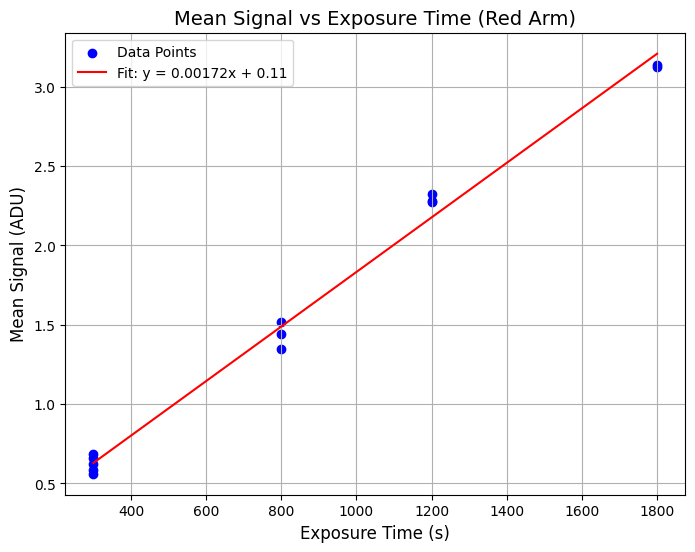

Red Arm:
Slope: 0.00 ADU/s
Dark Current: 8.23 electrons/hour
R-squared: 0.99


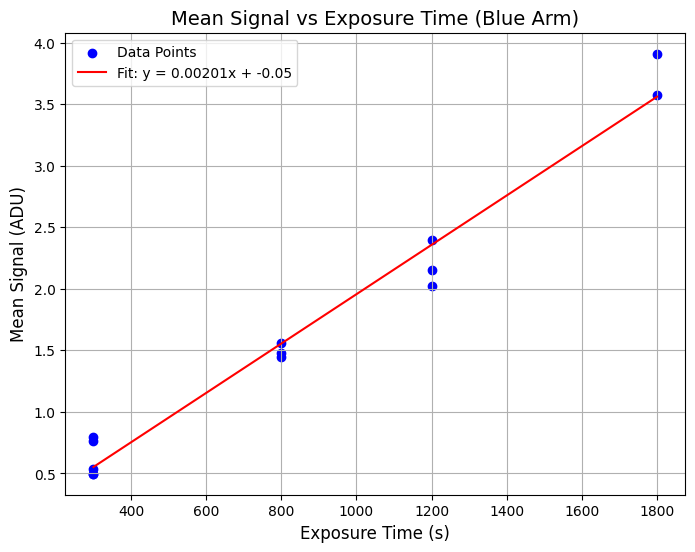

Blue Arm:
Slope: 0.00 ADU/s
Dark Current: 11.63 electrons/hour
R-squared: 0.97


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from scipy.stats import linregress

# Function to process dark frames and calculate dark current
def process_dark_frames(dark_folder, arm_name, gain):
    dark_files = [os.path.join(dark_folder, f) for f in os.listdir(dark_folder) if f.lower().endswith(".fits")]
    exposure_times = []
    mean_signals = []

    for dark_file in dark_files:
        with fits.open(dark_file) as hdul:
            header = hdul[0].header
            data = hdul[0].data

            # Extract exposure time from the header
            exptime = header.get("EXPTIME", None)
            if exptime is None:
                print(f"Exposure time not found in {dark_file}, skipping.")
                continue

            # Calculate the mean pixel value in the dark frame
            mean_pixel_value = np.mean(data)

            # Append results
            exposure_times.append(exptime)
            mean_signals.append(mean_pixel_value)

    # Sort data by exposure time
    exposure_times = np.array(exposure_times)
    mean_signals = np.array(mean_signals)
    sorted_indices = np.argsort(exposure_times)
    exposure_times = exposure_times[sorted_indices]
    mean_signals = mean_signals[sorted_indices]

    # Perform a linear fit to calculate the slope
    slope, intercept, r_value, p_value, std_err = linregress(exposure_times, mean_signals)

    # Calculate dark current in electrons/hour
    dark_current = slope * gain * 3600  # Convert to electrons/hour

    # Plot mean signal vs. exposure time
    plt.figure(figsize=(8, 6))
    plt.scatter(exposure_times, mean_signals, color="blue", label="Data Points")
    plt.plot(exposure_times, slope * exposure_times + intercept, color="red", label=f"Fit: y = {slope:.5f}x + {intercept:.2f}")
    plt.title(f"Mean Signal vs Exposure Time ({arm_name} Arm)", fontsize=14)
    plt.xlabel("Exposure Time (s)", fontsize=12)
    plt.ylabel("Mean Signal (ADU)", fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True)
    plt.show()

    # Print results
    print(f"{arm_name} Arm:")
    print(f"Slope: {slope:.2f} ADU/s")
    print(f"Dark Current: {dark_current:.2f} electrons/hour")
    print(f"R-squared: {r_value**2:.2f}")

# Paths to the dark folders
darks_red_folder = "/Users/Ishfahanirusyda/Documents/Obstech/Darks/Red"
darks_blue_folder = "/Users/Ishfahanirusyda/Documents/Obstech/Darks/Blue"

# Process data for both arms with respective gains
gain_red = 1.33
gain_blue = 1.61
process_dark_frames(darks_red_folder, "Red", gain_red)
process_dark_frames(darks_blue_folder, "Blue", gain_blue)

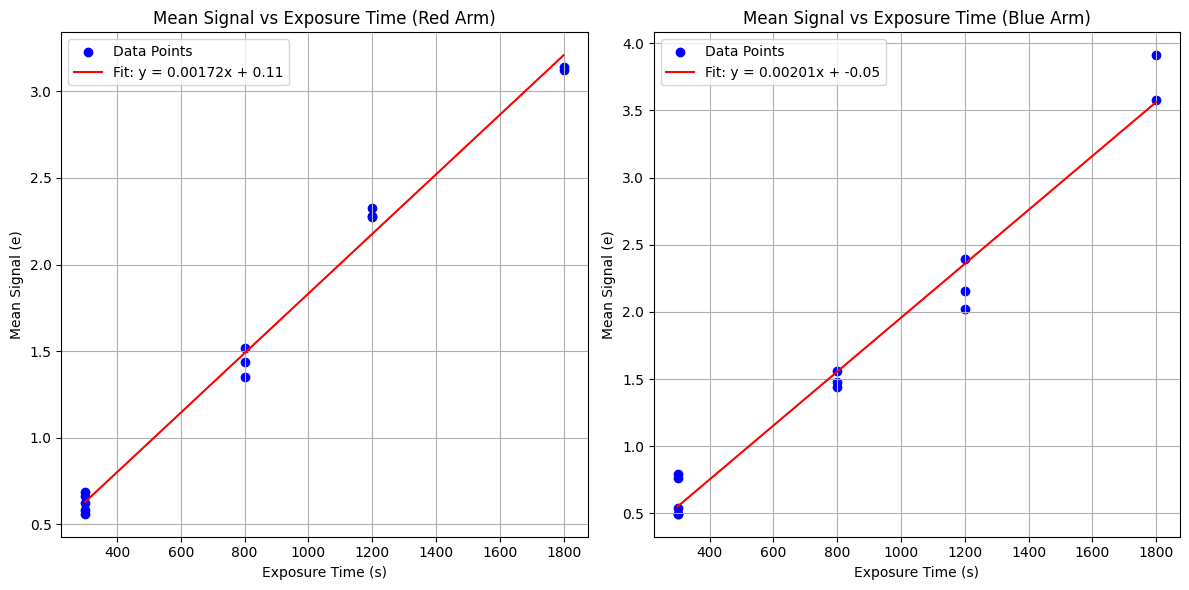

Red Arm:
Slope: 0.00172 ADU/s
Dark Current: 8.23 electrons/hour
R-squared: 0.99

Blue Arm:
Slope: 0.00201 ADU/s
Dark Current: 11.63 electrons/hour
R-squared: 0.97


In [ ]:
# Function to process dark frames and calculate dark current
def process_dark_frames(dark_folder, arm_name, gain):
    dark_files = [os.path.join(dark_folder, f) for f in os.listdir(dark_folder) if f.lower().endswith(".fits")]
    exposure_times = []
    mean_signals = []

    for dark_file in dark_files:
        with fits.open(dark_file) as hdul:
            header = hdul[0].header
            data = hdul[0].data

            # Extract exposure time from the header
            exptime = header.get("EXPTIME", None)
            if exptime is None:
                print(f"Exposure time not found in {dark_file}, skipping.")
                continue

            # Calculate the mean pixel value in the dark frame
            mean_pixel_value = np.mean(data)

            # Append results
            exposure_times.append(exptime)
            mean_signals.append(mean_pixel_value)

    # Sort data by exposure time
    exposure_times = np.array(exposure_times)
    mean_signals = np.array(mean_signals)
    sorted_indices = np.argsort(exposure_times)
    exposure_times = exposure_times[sorted_indices]
    mean_signals = mean_signals[sorted_indices]

    # Perform a linear fit to calculate the slope
    slope, intercept, r_value, p_value, std_err = linregress(exposure_times, mean_signals)

    # Calculate dark current in electrons/hour
    dark_current = slope * gain * 3600  # Convert to electrons/hour

    return exposure_times, mean_signals, slope, intercept, r_value, dark_current

# Paths to the dark folders
darks_red_folder = "/Users/Ishfahanirusyda/Documents/Obstech/Darks/Red"
darks_blue_folder = "/Users/Ishfahanirusyda/Documents/Obstech/Darks/Blue"

# Process data for both arms with respective gains
gain_red = 1.33
gain_blue = 1.61
exposure_times_red, mean_signals_red, slope_red, intercept_red, r_value_red, dark_current_red = process_dark_frames(darks_red_folder, "Red", gain_red)
exposure_times_blue, mean_signals_blue, slope_blue, intercept_blue, r_value_blue, dark_current_blue = process_dark_frames(darks_blue_folder, "Blue", gain_blue)

# Create a single figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot for the red arm
axes[0].scatter(exposure_times_red, mean_signals_red, color="blue", label="Data Points")
axes[0].plot(exposure_times_red, slope_red * exposure_times_red + intercept_red, color="red", label=f"Fit: y = {slope_red:.5f}x + {intercept_red:.2f}")
axes[0].set_title("Mean Signal vs Exposure Time (Red Arm)", fontsize=12)
axes[0].set_xlabel("Exposure Time (s)", fontsize=10)
axes[0].set_ylabel("Mean Signal (e)", fontsize=10)
axes[0].legend(fontsize=10)
axes[0].grid(True)

# Plot for the blue arm
axes[1].scatter(exposure_times_blue, mean_signals_blue, color="blue", label="Data Points")
axes[1].plot(exposure_times_blue, slope_blue * exposure_times_blue + intercept_blue, color="red", label=f"Fit: y = {slope_blue:.5f}x + {intercept_blue:.2f}")
axes[1].set_title("Mean Signal vs Exposure Time (Blue Arm)", fontsize=12)
axes[1].set_xlabel("Exposure Time (s)", fontsize=10)
axes[1].set_ylabel("Mean Signal (e)", fontsize=10)
axes[1].legend(fontsize=10)
axes[1].grid(True)

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

# Print results
print("Red Arm:")
print(f"Slope: {slope_red:.5f} ADU/s")
print(f"Dark Current: {dark_current_red:.2f} electrons/hour")
print(f"R-squared: {r_value_red**2:.2f}")

print("\nBlue Arm:")
print(f"Slope: {slope_blue:.5f} ADU/s")
print(f"Dark Current: {dark_current_blue:.2f} electrons/hour")
print(f"R-squared: {r_value_blue**2:.2f}")